# Fractal Analysis of Music Signals

## 1. Setup and Imports

In [1]:
import os

os.environ['OMP_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['NUMEXPR_NUM_THREADS']  = '1'

BASE_PATH = 'data/dataset_archive/musicnet/musicnet'
N_JOBS    = 10        # 12 физ. ядер M2 Pro
OUT_DIR   = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, resample
from scipy.spatial.distance import pdist
from scipy.spatial import cKDTree

## 2. Core Utility Functions
### 2.1 Audio Loading

In [3]:
def load_and_downsample_audio(audio_path, target_sr=22050, duration_sec=15.0,
                               downsample_factor=1, mono=True):
    y, sr = librosa.load(audio_path, sr=target_sr, mono=mono, duration=duration_sec)

    # Нормировка
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))

    # Downsampling если требуется
    if downsample_factor > 1:
        n_samples = len(y) // downsample_factor
        y = resample(y, n_samples)
        sr = sr // downsample_factor
        print(f"Downsampled by factor {downsample_factor}: {target_sr} Hz -> {sr} Hz")

    print(f"Loaded: {len(y)} samples, {len(y)/sr:.2f} sec, SR: {sr} Hz")
    return y, sr


### 2.2 Time Delay Embedding

In [4]:
def delay_embed(x, m, tau):
    """
    Create m vectors of delayed data from time series.
    z_i = [x_i, x_(i+tau), x_(i+2*tau), ..., x_(i + tau*(m-1))]
    """
    x = np.asarray(x, float)
    N = len(x)

    if (m - 1) * tau >= N:
        raise ValueError(f"(m-1)*tau = {(m-1)*tau} >= len(x) = {N}")

    n_vectors = N - (m - 1) * tau
    Z = np.zeros((n_vectors, m))

    for i in range(m):
        Z[:, i] = x[i * tau : i * tau + n_vectors]

    return Z

def z_normalize(x, eps=1e-9):
    """Z-score normalization"""
    x = np.asarray(x, float)

    return (x - np.mean(x)) / (np.std(x) + eps)

### 2.3 Tau Selection Methods

In [5]:
def autocorrelation_function(
    x, max_lag=400,
    normalize=True,
    acf_select='first_1e', # 'first_1e' | 'first_zero' | 'min_after'
    acf_min_lag=1
):
    """
    Calculates Autocorrelation Function (ACF) and selects tau.
    """
    x = np.asarray(x, float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    N = len(x)
    acf = np.correlate(x, x, mode='full')
    acf = acf[N-1:]

    if normalize and acf[0] != 0:
        acf = acf / acf[0]

    acf = acf[:max_lag]

    tau_acf = int(max(acf_min_lag, 1))
    tail = acf[1:] if acf.size > 1 else np.array([])

    if acf_select == 'first_1e':
        thr = 1.0 / np.e
        idx = np.where(tail <= thr)[0]
        if idx.size > 0:
            candidate = idx[0] + 1
            if candidate >= acf_min_lag:
                tau_acf = int(candidate)

    elif acf_select == 'first_zero':
        idx = np.where(tail <= 0)[0]
        if idx.size > 0:
            candidate = idx[0] + 1
            if candidate >= acf_min_lag:
                tau_acf = int(candidate)

    else: # 'min_after'
        peaks, _ = find_peaks(-tail)
        if peaks.size > 0:
            candidate = peaks[0] + 1
            if candidate >= acf_min_lag:
                tau_acf = int(candidate)

    return acf, tau_acf, {'ACF': acf}




def average_mutual_information(
    x, max_lag=400, n_bins=64, smooth=3,
    ami_select='first_min', # 'first_min' | 'global_min'
    ami_min_lag=1,
    ami_min_prominence=0.01
):
    """
    Calculates Average Mutual Information (AMI) using global binning.
    """
    x = np.asarray(x, float)
    N = len(x)

    x_min, x_max = np.min(x), np.max(x)
    bins = np.linspace(x_min, x_max + 1e-10, n_bins + 1)

    x_binned = np.digitize(x, bins) - 1
    x_binned = np.clip(x_binned, 0, n_bins - 1)

    px, _ = np.histogram(x, bins=bins, density=False)
    px = px / N

    AMI = np.zeros(max_lag, dtype=float)

    log_px = np.zeros_like(px)
    mask = px > 0
    log_px[mask] = np.log(px[mask])

    for k in range(1, max_lag + 1):
        i_indices = x_binned[:-k]
        j_indices = x_binned[k:]

        flat_indices = i_indices * n_bins + j_indices
        pxy_flat = np.bincount(flat_indices, minlength=n_bins*n_bins)
        pxy = pxy_flat.reshape(n_bins, n_bins)

        pxy = pxy / (N - k)
        mask_xy = pxy > 0

        mi_val = np.sum(pxy[mask_xy] * np.log(pxy[mask_xy]))

        log_px_sum = log_px[:, None] + log_px[None, :]
        mi_val -= np.sum(pxy[mask_xy] * log_px_sum[mask_xy])

        AMI[k - 1] = mi_val

    if smooth and smooth > 1:
        w = np.ones(smooth) / smooth
        AMI = np.convolve(AMI, w, mode='same')

    peaks, _ = find_peaks(-AMI, prominence=ami_min_prominence)
    minima = (peaks + 1)
    minima = minima[minima >= ami_min_lag]

    if ami_select == 'global_min':
        if len(minima) > 0:
             min_vals = AMI[minima - 1]
             tau_ami = int(minima[np.argmin(min_vals)])
        else:
             tau_ami = int(np.argmin(AMI) + 1)
    else: # first_min
        tau_ami = int(minima[0]) if len(minima) else int(max(ami_min_lag, 1))

    info = {'minima': minima.tolist(), 'AMI': AMI}

    return AMI, tau_ami, info


### 2.4 Base fractals

In [6]:
# 2D versions
def cantor_set(n_iter=14):
    """
    Множество Кантора: D_теор = 0.6309
    """
    pts = np.array([0.5])
    for _ in range(n_iter):
        pts = np.concatenate([pts / 3, pts / 3 + 2/3])

    return pts.reshape(-1, 1)

def koch_curve(n_iter=7):
    """
    Кривая Коха: D_теор = 1.2619
    """
    pts = np.array([[0.0, 0.0], [1.0, 0.0]])
    for _ in range(n_iter):
        new = []
        for i in range(len(pts) - 1):
            A, B = pts[i], pts[i+1]
            d = B - A
            P1 = A + d / 3
            P2 = A + d / 2 + np.array([-d[1], d[0]]) * np.sqrt(3) / 6
            P3 = A + 2 * d / 3
            new.extend([A, P1, P2, P3])

        new.append(pts[-1])
        pts = np.array(new)

    return pts

def sierpinski_triangle(n_iter=12):
    """Треугольник Серпинского: D_теор = 1.5850"""
    corners = np.array([[0,0],[1,0],[0.5, np.sqrt(3)/2]])
    pt = corners[0].copy()
    pts = [pt.copy()]
    rng = np.random.default_rng(42)
    for _ in range(n_iter * 5000):
        c = corners[rng.integers(3)]
        pt = (pt + c) / 2
        pts.append(pt.copy())

    return np.array(pts)

def sierpinski_carpet(n_iter=6):
    """Ковёр Серпинского: D_теор = 1.8928"""
    pts = np.array([[0.5, 0.5]])
    for _ in range(n_iter):
        new = []
        offsets = [(i, j) for i in range(3) for j in range(3) if not (i == 1 and j == 1)]
        for ox, oy in offsets:
            new.append(pts / 3 + np.array([ox/3, oy/3]))

        pts = np.vstack(new)

    return pts

In [7]:
# 3D versions
def sierpinski_tetrahedron_3d(n_points=20000, seed=0):
    """
    Тетраэдр Серпинского через "chaos game" (Iterated Function System).
    Теоретическая размерность D = log(4)/log(2) = 2.0
    """
    rng = np.random.default_rng(seed)
    vertices = np.array([
        [0, 0, 0],
        [1, 0, 0],
        [0.5, np.sqrt(3)/2, 0],
        [0.5, np.sqrt(3)/6, np.sqrt(2/3)],
    ])
    p = vertices[0].copy()
    pts = np.zeros((n_points, 3))
    for _ in range(50):
        v = vertices[rng.integers(4)]
        p = (p + v) / 2
    for i in range(n_points):
        v = vertices[rng.integers(4)]
        p = (p + v) / 2
        pts[i] = p
    return pts

def menger_sponge_3d(n_iter=4, max_points=30000):
    """
    Губка Менгера через многократное деление куба.
    Теоретическая размерность D = log(20)/log(3) ≈ 2.727
    """
    removed = {(1,1,1), (0,1,1), (2,1,1), (1,0,1), (1,2,1), (1,1,0), (1,1,2)}
    keep = [(i,j,k) for i in range(3) for j in range(3) for k in range(3) if (i,j,k) not in removed]
    keep = np.array(keep, dtype=float)  # (20, 3)

    points = np.array([[0.0, 0.0, 0.0]])
    scale = 1.0

    for it in range(n_iter):
        scale /= 3.0
        offsets = (keep - 1) * scale
        new_points = (points[:, None, :] + offsets[None, :, :]).reshape(-1, 3)
        points = new_points
        if len(points) > max_points:
            idx = np.random.default_rng(0).choice(len(points), max_points, replace=False)
            points = points[idx]
            break

    return points

def vicsek_3d(n_iter=4, max_points=20000):
    """
    3D-фрактал Вичека: куб 27 подкубов, оставляем центр + 6 граней = 7 штук.
    D = log(7)/log(3) ≈ 1.771
    """
    keep = np.array([
        (1,1,1),
        (0,1,1), (2,1,1),
        (1,0,1), (1,2,1),
        (1,1,0), (1,1,2),
    ], dtype=float)

    points = np.array([[0.0, 0.0, 0.0]])
    scale = 1.0

    for it in range(n_iter):
        scale /= 3.0
        offsets = (keep - 1) * scale
        new_points = (points[:, None, :] + offsets[None, :, :]).reshape(-1, 3)
        points = new_points
        if len(points) > max_points:
            idx = np.random.default_rng(0).choice(len(points), max_points, replace=False)
            points = points[idx]
            break

    return points

def cantor_dust_3d(n_iter=5, max_points=20000):
    """
    3D-кантор: куб 27 подкубов, оставляем 8 угловых.
    D = log(8)/log(3) ≈ 1.893
    """
    keep = np.array([(i,j,k) for i in (0,2) for j in (0,2) for k in (0,2)], dtype=float)

    points = np.array([[0.0, 0.0, 0.0]])
    scale = 1.0

    for it in range(n_iter):
        scale /= 3.0
        offsets = (keep - 1) * scale
        new_points = (points[:, None, :] + offsets[None, :, :]).reshape(-1, 3)
        points = new_points
        if len(points) > max_points:
            idx = np.random.default_rng(0).choice(len(points), max_points, replace=False)
            points = points[idx]
            break

    return points


### 2.5 Dimension counting methods

In [30]:
def box_counting_dimension(X, epsilons=None, fit_slice=(0.3, 0.8)):
    """
    Оценка Minkowski (box-counting) D для точек X в R^m.
    Возвращает (D, info), где info содержит Ns, eps и наклон.
    """
    X = np.asarray(X, float)
    mins = X.min(axis=0)
    rng = np.maximum(X.max(axis=0) - mins, 1e-12)
    Y = (X - mins) / rng

    if epsilons is None:
        epsilons = np.logspace(-1.7, -0.1, 14)

    Ns = []
    for eps in epsilons:
        cells = np.floor(Y / eps).astype(np.int64)
        if len(cells) == 0:
            Ns.append(0)
        else:
            uniq = np.unique(cells.view([('', cells.dtype)]*cells.shape[1]))
            Ns.append(len(uniq))

    Ns = np.array(Ns, float)
    mask = Ns > 1
    if np.sum(mask) < 3:
        return np.nan, {'eps': epsilons, 'N': Ns}

    x = np.log(1.0/epsilons[mask])
    y = np.log(Ns[mask])
    L = len(y)
    a = max(0, int(L*fit_slice[0]))
    b = max(a+2, int(L*fit_slice[1]))
    slope, inter = np.polyfit(x[a:b], y[a:b], 1)
    yhat = slope*x[a:b] + inter
    r2 = 1 - np.sum((y[a:b] - yhat)**2) / (np.sum((y[a:b] - np.mean(y[a:b]))**2) + 1e-12)

    return float(slope), {'eps': epsilons, 'N': Ns, 'slope': float(slope), 'r2': float(r2), 'fit_idx': (a,b)}

# D2 correlation dimension method
def correlation_dimension(X, r_vals=None, sample_max=3000, fit_slice=(0.3, 0.8), seed=0):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, float)

    if not np.all(np.isfinite(X)):
        return np.nan, {'r': None, 'C': None}

    if len(X) > sample_max:
        idx = rng.choice(len(X), size=sample_max, replace=False)
        Xs = X[idx]
    else:
        Xs = X

    d = pdist(Xs, metric='euclidean')
    d = d[np.isfinite(d)]
    if len(d) < 1000:
        return np.nan, {'r': None, 'C': None}

    d_sorted = np.sort(d)
    d_min = np.percentile(d_sorted, 1)
    d_max = np.percentile(d_sorted, 60)

    if d_max <= d_min or d_min <= 0:
        return np.nan, {'r': None, 'C': None}

    if r_vals is None:
        r_vals = np.logspace(np.log10(d_min), np.log10(d_max), 20)

    n = len(Xs)
    M = n*(n-1)/2.0
    C = np.array([np.searchsorted(d_sorted, r, side='right')/M for r in r_vals])

    x = np.log(r_vals)
    y = np.log(C + 1e-12)
    L = len(y)
    a = max(0, int(L*fit_slice[0]))
    b = max(a+2, int(L*fit_slice[1]))

    if b - a < 3:
        return np.nan, {'r': r_vals, 'C': C}

    slope, inter = np.polyfit(x[a:b], y[a:b], 1)
    yhat = slope*x[a:b] + inter
    r2 = 1 - np.sum((y[a:b] - yhat)**2) / (np.sum((y[a:b] - np.mean(y[a:b]))**2) + 1e-12)

    return float(slope), {'r': r_vals, 'C': C, 'slope': float(slope), 'r2': float(r2), 'fit_idx': (a,b)}

In [9]:
from scipy.spatial.distance import squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.stats import norm


from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import minimum_spanning_tree

def _build_mst_edges(X, k=15):
    """MST через k-NN граф"""
    n = len(X)
    if n <= 200:
        # Для маленьких N плотная матрица быстрее
        from scipy.spatial.distance import pdist, squareform
        D = squareform(pdist(X, metric='euclidean'))
        mst = minimum_spanning_tree(D).tocoo()
    else:
        G = kneighbors_graph(X, n_neighbors=min(k, n-1),
                             mode='distance', include_self=False)
        # симметризуем для корректного MST
        G = G.maximum(G.T)
        mst = minimum_spanning_tree(G).tocoo()

    edges = mst.data

    # степени: каждое ребро добавляет 1 каждой из двух вершин
    deg = np.bincount(np.concatenate([mst.row, mst.col]), minlength=n)

    return edges, deg



# расчёт размерности методом Швайнхарта
def schweinhart_dimension(X, alphas=None, sample_sizes=None, seed=42):
    rng = np.random.default_rng(seed)
    N = len(X)

    if alphas is None:
        alphas = np.arange(0.1, 5.0, 0.2)
    if sample_sizes is None:
        sample_sizes = np.unique(np.geomspace(
            max(30, N // 50), min(N, 3000), num=10
        ).astype(int))

    results = {}
    ci = {}
    details = {}

    for alpha in alphas:
        ln_ells = []
        ln_E_alphas = []

        for ell in sample_sizes:
            if ell > N:
                continue
            idx = rng.choice(N, size=ell, replace=False)
            sub = X[idx]
            edges, _ = _build_mst_edges(sub)
            E_alpha = np.sum(edges ** alpha)
            if E_alpha > 0:
                ln_ells.append(np.log(ell))
                ln_E_alphas.append(np.log(E_alpha))

        ln_ells = np.array(ln_ells)
        ln_E_alphas = np.array(ln_E_alphas)

        if len(ln_ells) < 4:
            continue

        coeffs = np.polyfit(ln_ells, ln_E_alphas, 1)
        slope, intercept = coeffs[0], coeffs[1]

        predicted = slope * ln_ells + intercept
        ss_res = np.sum((ln_E_alphas - predicted) ** 2)
        ss_tot = np.sum((ln_E_alphas - np.mean(ln_E_alphas)) ** 2)
        r_sq = 1 - ss_res / ss_tot if ss_tot > 1e-15 else 0

        if slope < 0.99 and (1.0 - slope) > 0.01:
            d_hat = alpha / (1.0 - slope)
            if 0 < d_hat < 100:
                n_pts = len(ln_ells)
                Sxx = np.sum((ln_ells - np.mean(ln_ells))**2)
                se_slope = np.sqrt(ss_res / (n_pts - 2) / Sxx) if n_pts > 2 and Sxx > 1e-15 else np.inf
                se_d = se_slope * alpha / (1 - slope)**2
                results[alpha] = d_hat
                ci[alpha] = (d_hat - 1.96 * se_d, d_hat + 1.96 * se_d)
                details[alpha] = {'slope': slope, 'intercept': intercept, 'r_squared': r_sq, 'se_d': se_d}

    gamma = 0.10
    valid = {}
    valid_ci = {}
    for a in results:
        width = ci[a][1] - ci[a][0]
        if abs(results[a]) > 1e-10 and width < gamma * abs(results[a]) * 2:
            valid[a] = results[a]
            valid_ci[a] = ci[a]

    if not valid:
        by_r2 = sorted(details.items(), key=lambda x: -x[1]['r_squared'])
        for a, d in by_r2[:5]:
            if a in results:
                valid[a] = results[a]
                valid_ci[a] = ci[a]

    if not valid:
        valid = results
        valid_ci = ci

    median_d = np.median(list(valid.values())) if valid else np.nan

    return {
        'd_estimates': results, 'ci': ci,
        'valid_estimates': valid, 'valid_ci': valid_ci,
        'median_d': median_d, 'details': details
    }


# расчёт размерности методом Брито
def brito_dimension(X, max_dim=10, K=100, sample_size=500, seed=42):
    rng = np.random.default_rng(seed)
    N = len(X)
    ell = min(sample_size, N)

    idx = rng.choice(N, size=ell, replace=False)
    _, degrees = _build_mst_edges(X[idx])
    M_real = np.mean(degrees ** 2)

    mu_hat = {}
    sigma2_hat = {}
    for i in range(1, max_dim + 1):
        M_samples = []
        for _ in range(K):
            pts = rng.uniform(0, 1, size=(ell, i))
            _, deg = _build_mst_edges(pts)
            M_samples.append(np.mean(deg ** 2))
        M_samples = np.array(M_samples)
        mu_hat[i] = np.mean(M_samples)
        sigma2_hat[i] = np.var(M_samples, ddof=1) * ell

    log_likes = {}
    for i in range(1, max_dim + 1):
        var_i = sigma2_hat[i] / ell
        log_likes[i] = norm.logpdf(M_real, loc=mu_hat[i], scale=np.sqrt(var_i)) if var_i > 1e-15 else -np.inf

    max_ll = max(log_likes.values())
    if np.isfinite(max_ll):
        denom = max_ll + np.log(sum(np.exp(log_likes[j] - max_ll) for j in log_likes))
        probs = {i: np.exp(log_likes[i] - denom) for i in log_likes}
    else:
        probs = {i: 1.0 / max_dim for i in range(1, max_dim + 1)}

    d_expected = sum(i * probs[i] for i in probs)
    d_brito = int(round(d_expected))

    return {
        'd_brito': d_brito, 'd_expected': d_expected,
        'probabilities': probs, 'M_real': M_real
    }


### 2.6 Another utils

In [10]:
def false_nearest_neighbors(x, tau, m_max=12, Rtol=15.0, Atol=2.0, sample_max=5000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float).flatten()

    N_required = len(x) - m_max * tau
    if N_required <= 0:
        raise ValueError(
            f"Ряд слишком короткий для m_max={m_max} и tau={tau}. "
            f"Нужно минимум {m_max * tau + 1} точек, есть {len(x)}."
        )

    std_x = np.std(x)
    if std_x < 1e-12:
        std_x = 1.0

    fnn_percent = []

    for m in range(1, m_max + 1):
        N_m = len(x) - m * tau
        N_m1 = len(x) - (m + 1) * tau

        if N_m1 <= 1:
            fnn_percent.append(np.nan)
            continue

        # X_m[i] = [x[i], x[i+tau], ..., x[i+(m-1)*tau]]
        X_m = np.zeros((N_m, m))
        for k in range(m):
            X_m[:, k] = x[k * tau : k * tau + N_m]

        # X_m1 — первые N_m1 точек, но с добавлением (m+1)-й координаты
        X_m1 = np.zeros((N_m1, m + 1))
        for k in range(m + 1):
            X_m1[:, k] = x[k * tau : k * tau + N_m1]

        if N_m1 > sample_max:
            idx_sample = np.sort(rng.choice(N_m1, size=sample_max, replace=False))
        else:
            idx_sample = np.arange(N_m1)

        n_sample = len(idx_sample)

        # KD-дерево для m-мерного эмбеддинга (только первые N_m1 точек)
        X_m_subset = X_m[:N_m1]
        tree = cKDTree(X_m_subset)

        # Для каждой точки находим ближайшего соседа (k=2: сама точка + сосед)
        X_query = X_m_subset[idx_sample]
        distances, indices = tree.query(X_query, k=2)

        # distances[:, 0] — расстояние до себя (0)
        # distances[:, 1] — расстояние до ближайшего соседа
        # indices[:, 1] — индекс ближайшего соседа
        d_m = distances[:, 1]
        nn_indices = indices[:, 1]

        d_m = np.maximum(d_m, 1e-12)

        X_m1_sample = X_m1[idx_sample]
        X_m1_neighbors = X_m1[nn_indices]
        d_m1 = np.linalg.norm(X_m1_sample - X_m1_neighbors, axis=1)

        # Критерий 1: относительное увеличение расстояния
        ratio = d_m1 / d_m
        criterion_1 = ratio > Rtol

        # Критерий 2: абсолютное увеличение в (m+1)-й координате
        delta_new_coord = np.abs(X_m1_sample[:, -1] - X_m1_neighbors[:, -1])
        criterion_2 = (delta_new_coord / std_x) > Atol

        is_fnn = criterion_1 | criterion_2

        percent = 100.0 * np.sum(is_fnn) / n_sample
        fnn_percent.append(percent)

    return np.array(fnn_percent, dtype=float)


In [11]:
def concatenate_tracks(loader, track_ids, split='test', target_sr=5512, duration_per_track=None, fade_ms=100):
    chunks, lens_ok = [], 0
    for tid in track_ids:
        y, sr = loader.load_track(tid, split=split, sr=target_sr)
        if duration_per_track:
            n = int(duration_per_track * target_sr)
            y = y[:n]
        # fade in/out
        fade_n = int(fade_ms/1000 * target_sr)
        if len(y) > 2*fade_n:
            y[:fade_n]  *= np.linspace(0, 1, fade_n)
            y[-fade_n:] *= np.linspace(1, 0, fade_n)
        chunks.append(y.astype(np.float32))  # float32, не float64!
        lens_ok += 1
    return np.concatenate(chunks), target_sr


In [31]:
import time, gc

def dimension_vs_embedding(
    x, tau,
    m_list=(2, 3, 4, 5, 6, 7, 8, 10, 12),
    corr_sample_max=2500,
    schw_sample_max=1500,
    schw_alphas=None,
    max_series_len=200_000,
    seed=0,
    verbose=True,
):
    """
    D2 (correlation) и D_Schw (Schweinhart MST) для разных m.
    Memory-safe для Kaggle (16 GB RAM).

    Алгоритм:
      1) Если len(x) > max_series_len — берём случайную смежную выборку.
      2) Используем delay_embed (view через stride_tricks), без копии.
      3) Subsample для D2 / Schw, считаем размерности.
      4) Явный gc.collect() между m.

    Возвращает dict: {'m_list', 'D2', 'D_schw', 'N_used', 'N_corr', 'N_schw', 'elapsed'}.
    """
    rng = np.random.default_rng(seed)
    if schw_alphas is None:
        schw_alphas = np.arange(0.5, 3.1, 0.5)

    # 1) Прореживание x
    x = np.asarray(x, dtype=np.float32)  # float32 → вдвое меньше памяти
    if len(x) > max_series_len:
        # случайный смежный кусок (а НЕ x[::stride], чтобы сохранить корреляции)
        start = rng.integers(0, len(x) - max_series_len)
        x_use = x[start : start + max_series_len].copy()
        if verbose:
            print(f"x trimmed: {len(x)} → {len(x_use)} (chunk [{start}:{start+max_series_len}])")
    else:
        x_use = x

    N_total = len(x_use)
    D2_vec, Dschw_vec = [], []
    N_corr_vec, N_schw_vec = [], []
    t_start = time.time()

    for m in m_list:
        N = N_total - (m - 1) * tau
        if N <= 200:
            if verbose: print(f"  m={m}: ряд слишком короткий (N={N})")
            D2_vec.append(np.nan); Dschw_vec.append(np.nan)
            N_corr_vec.append(N);  N_schw_vec.append(N)
            continue


        # 2) delay_embed как view, без копии
        Z = delay_embed(x_use, m=m, tau=tau)

        # 3) Адаптивный размер подвыборки (больше m -> меньше точек, чтобы pdist влез)
        n_c = min(N, corr_sample_max)
        n_s = min(N, schw_sample_max)
        if m >= 10:
            n_c = int(n_c * 0.8)
            n_s = int(n_s * 0.8)
        if m >= 15:
            n_c = int(n_c * 0.7)
            n_s = int(n_s * 0.7)

        # D2
        try:
            idx_c = rng.choice(N, n_c, replace=False)
            Z_c = np.ascontiguousarray(Z[idx_c], dtype=np.float32)  # копия только из n_c строк
            D2, _ = correlation_dimension(Z_c, r_vals=None, sample_max=n_c,
                                          fit_slice=(0.3, 0.8), seed=seed)
            del Z_c
        except (MemoryError, Exception) as e:
            if verbose: print(f"  m={m}: D2 failed: {type(e).__name__}: {e}")
            D2 = np.nan

        # D_Schw
        try:
            idx_s = rng.choice(N, n_s, replace=False)
            Z_s = np.ascontiguousarray(Z[idx_s], dtype=np.float32)
            sample_sizes = np.unique(np.geomspace(max(30, n_s // 50), n_s, num=6).astype(int))
            schw_res = schweinhart_dimension(Z_s, alphas=schw_alphas,
                                             sample_sizes=sample_sizes, seed=seed)
            D_schw = schw_res['median_d']
            del Z_s, schw_res
        except (MemoryError, Exception) as e:
            if verbose: print(f"  m={m}: Schw failed: {type(e).__name__}: {e}")
            D_schw = np.nan

        del Z
        gc.collect()

        D2_vec.append(D2); Dschw_vec.append(D_schw)
        N_corr_vec.append(n_c); N_schw_vec.append(n_s)

        if verbose:
            elapsed = time.time() - t_start
            print(f"  m={m:2d}: D2={D2:.3f}, D_Schw={D_schw:.3f}, "
                  f"n_corr={n_c}, n_schw={n_s}, [{elapsed:.1f}s]")

    return {
        'm_list':  list(m_list),
        'D2':      np.array(D2_vec),
        'D_schw':  np.array(Dschw_vec),
        'N_used':  N_total,
        'N_corr':  N_corr_vec,
        'N_schw':  N_schw_vec,
        'elapsed': time.time() - t_start,
        'tau':     int(tau),
    }


## 3. Main Analysis Function

In [32]:
def fractal_analysis(
        y,
        sr,
        series_name='wave',   # 'wave' | 'centroid' | 'rms' | 'mfcc1' | 'bandwidth' | 'zcr' | 'mel_spec'
        hop_length=256,
        ami_max_lag=400,
        ami_min_lag=5,
        fnn_m_max=12,
        fnn_Rtol=15.0,
        fnn_Atol=2.0,
        corr_sample_max=3000,
        seed=0,
        verbose=True
    ):
    """
    1) строим 1D ряд из аудио,
    2) выбираем задержку tau через AMI (first local minimum),
    3) выбираем размерность вложения m через FNN,
    4) строим delay embedding,
    5) считаем box-counting и correlation dimension.
    """

    y = np.asarray(y, dtype=float)
    if y.ndim != 1:
        raise ValueError("y должен быть одномерным аудиосигналом")
    if len(y) < 10:
        raise ValueError("Сигнал слишком короткий для анализа")

    def _clean_and_normalize_1d(x):
        x = np.asarray(x, dtype=float).copy()
        if x.ndim != 1:
            raise ValueError("Ожидался одномерный временной ряд")
        if len(x) < 10:
            raise ValueError("Ряд слишком короткий для анализа")

        bad = ~np.isfinite(x)
        if np.any(bad):
            good = ~bad
            if np.sum(good) < 2:
                raise ValueError("Недостаточно конечных значений в ряде")
            idx = np.arange(len(x))
            x[bad] = np.interp(idx[bad], idx[good], x[good])

        if np.std(x) < 1e-12:
            raise ValueError("Ряд почти константный, анализ неинформативен")

        return z_normalize(x)

    if series_name == 'wave':
        x = _clean_and_normalize_1d(y)
        series_used = 'wave'
        samples_per_step = 1

    else:
        S = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))

        if series_name == 'centroid':
            feat = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
        elif series_name == 'rms':
            feat = librosa.feature.rms(S=S)[0]
        elif series_name == 'mfcc1':
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=hop_length)
            feat = mfcc[0]
        elif series_name == 'bandwidth':
            feat = librosa.feature.spectral_bandwidth(S=S, sr=sr)[0]
        elif series_name == 'zcr':
            feat = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)[0]
        elif series_name == 'mel_spec':
            mel = librosa.feature.melspectrogram(y=y, sr=sr, hop_length=hop_length, n_mels=64)
            feat = librosa.power_to_db(mel, ref=np.max).mean(axis=0)
        else:
            raise ValueError(
                "series_name должен быть одним из: "
                "'wave', 'centroid', 'rms', 'mfcc1', 'bandwidth', 'zcr', 'mel_spec'"
            )

        x = _clean_and_normalize_1d(feat)
        series_used = series_name
        samples_per_step = hop_length

    max_allowed_lag = max(1, min(int(ami_max_lag), len(x) // 4))
    if max_allowed_lag <= ami_min_lag:
        max_allowed_lag = min(max(ami_min_lag + 1, 2), max(2, len(x) - 2))

    if max_allowed_lag <= ami_min_lag:
        raise ValueError(
            f"Ряд слишком короткий для выбора tau: len(x)={len(x)}, "
            f"ami_min_lag={ami_min_lag}"
        )

    AMI, tau, ami_info = average_mutual_information(
        x,
        max_lag=max_allowed_lag,
        n_bins=24,
        smooth=21,
        ami_select='first_min',
        ami_min_lag=ami_min_lag,
        ami_min_prominence=None
    )
    tau = int(tau)

    # ACF — чтобы потом сравнивать с AMI в plot_tau_comparison
    try:
        ACF, tau_acf, _ = autocorrelation_function(
            x,
            max_lag=max_allowed_lag,
            acf_select='first_zero',     # или 'one_over_e' / 'first_min'
            acf_min_lag=ami_min_lag,
        )
        tau_acf = int(tau_acf)
        ACF_list = np.asarray(ACF).tolist()
    except Exception:
        ACF_list, tau_acf = None, None


    FNN = false_nearest_neighbors(
        x,
        tau=tau,
        m_max=fnn_m_max,
        Rtol=fnn_Rtol,
        Atol=fnn_Atol,
        sample_max=5000,
        seed=seed
    )

    thr = 5.0
    below = np.where(FNN < thr)[0]
    if len(below) > 0:
        m = int(below[0] + 1)
    else:
        m = int(np.nanargmin(FNN) + 1)

    Z = delay_embed(x, m=m, tau=tau)

    D_box, info_box = box_counting_dimension(
        Z,
        epsilons=None,
        fit_slice=(0.3, 0.8)
    )

    D2, info_corr = correlation_dimension(
        Z,
        r_vals=None,
        sample_max=corr_sample_max,
        fit_slice=(0.3, 0.8),
        seed=seed
    )

    out = {
        'series': series_used,
        'tau_ami': int(tau),
        'tau_used': int(tau),
        'm': int(m),
        'D_box': float(D_box) if np.isfinite(D_box) else np.nan,
        'D2_corr': float(D2) if np.isfinite(D2) else np.nan,
        'FNN_percent': FNN.tolist(),
        'AMI': AMI.tolist(),
        'AMI_minima': ami_info.get('minima', []),
        'tau_acf': tau_acf,
        'ACF': ACF_list,
        'box_info': info_box,
        'corr_info': info_corr,
        'Z_shape': Z.shape,
        'samples_per_step': samples_per_step,
        'sr': sr,
        'hop_length': hop_length
    }

    if verbose:
        print(f"\n[{series_used}]")
        print(f"  τ_AMI = {out['tau_ami']}  (strategy=first_min, min_lag={ami_min_lag})")
        print(f"  τ_used = {out['tau_used']},  m = {out['m']}")
        print(f"  D_box = {out['D_box']:.3f}, D2 = {out['D2_corr']:.3f}")

    return out, x, Z


In [14]:
# analysis plottings
def plot_tau_comparison(result):
    """Сравнение AMI и ACF для выбора tau"""
    _, axes = plt.subplots(1, 2, figsize=(14, 4))

    # AMI (слева)
    if result.get('AMI') is not None:
        AMI = np.array(result['AMI'])
        lags = np.arange(1, len(AMI) + 1)
        axes[0].plot(lags, AMI, 'b-', linewidth=2, label='AMI')
        mins = np.array(result.get('AMI_minima', []), int)
        if len(mins) > 0:
            axes[0].scatter(mins, AMI[mins - 1], color='orange',
                            s=40, zorder=3, label='local minima')
        axes[0].axvline(result['tau_ami'], color='r', ls='--', linewidth=2,
                        label=f"τ_AMI = {result['tau_ami']}")
        axes[0].set_title('Average Mutual Information (AMI)')
        axes[0].set_xlabel('Lag'); axes[0].set_ylabel('Mutual Information')
        axes[0].legend(); axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'AMI not available',
                     ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('AMI (нет данных)')

    # ACF (справа)
    if result.get('ACF') is not None:
        ACF = np.array(result['ACF'])
        lags = np.arange(1, len(ACF) + 1)
        axes[1].plot(lags, ACF, 'g-', linewidth=2, label='ACF')
        axes[1].axhline(1.0 / np.e, color='gray', ls=':', label='порог 1/e')
        axes[1].axhline(0.0, color='k', linewidth=0.5)
        if result.get('tau_acf') is not None:
            axes[1].axvline(result['tau_acf'], color='r', ls='--', linewidth=2,
                            label=f"τ_ACF = {result['tau_acf']}")
        axes[1].set_title('Autocorrelation Function (ACF)')
        axes[1].set_xlabel('Lag'); axes[1].set_ylabel('ACF')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'ACF not available',
                     ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('ACF (нет данных)')

    plt.tight_layout()
    plt.show()


def plot_fnn_analysis(result):
    """График FNN для выбора m"""
    if result['FNN_percent'] is not None:
        plt.figure(figsize=(10, 5))
        m_values = np.arange(1, len(result['FNN_percent']) + 1)
        plt.plot(m_values, result['FNN_percent'], 'o-', markersize=7, linewidth=2, color='steelblue')
        plt.axhline(5, color='r', ls='--', linewidth=2, label='5% threshold')
        plt.axvline(result['m'], color='g', ls='--', linewidth=2, label=f"m = {result['m']}")
        plt.title('False Nearest Neighbors (FNN)')
        plt.xlabel('Embedding dimension m')
        plt.ylabel('% False Nearest Neighbors')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


def plot_dimension_fits(result):
    """Графики фитов для box-counting и correlation dimension"""
    _, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Box-counting
    box = result['box_info']
    mask = np.array(box['N']) > 1
    x_bc = np.log(1.0 / np.array(box['eps']))[mask]
    y_bc = np.log(np.array(box['N'])[mask])
    a, b = box['fit_idx']

    axes[0].plot(x_bc, y_bc, 'o-', markersize=6, linewidth=1.5, label='Data', color='steelblue')
    xx = x_bc[a:b]
    yy = box['slope'] * (xx - xx.mean()) + y_bc[a:b].mean()
    axes[0].plot(xx, yy, 'r--', linewidth=2.5,
                label=f"D_box = {box['slope']:.3f}, R^2 = {box['r2']:.3f}")
    axes[0].set_xlabel('log(1/ε)')
    axes[0].set_ylabel('log N(ε)')
    axes[0].set_title('Box-Counting (Minkowski) Dimension')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    corr = result['corr_info']
    if corr['r'] is not None:
        x_cr = np.log(np.array(corr['r']))
        y_cr = np.log(np.array(corr['C']) + 1e-12)
        a, b = corr['fit_idx']

        axes[1].plot(x_cr, y_cr, 'o-', markersize=6, linewidth=1.5, label='Data', color='darkgreen')
        xx = x_cr[a:b]
        yy = corr['slope'] * (xx - xx.mean()) + y_cr[a:b].mean()
        axes[1].plot(xx, yy, 'r--', linewidth=2.5,
                    label=f"D2 = {corr['slope']:.3f}, R^2 = {corr['r2']:.3f}")
        axes[1].set_xlabel('log r')
        axes[1].set_ylabel('log C(r)')
        axes[1].set_title('Correlation Dimension')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## 5. Topological Data Analysis (TDA)

Loaded: 330750 samples, 15.00 sec, SR: 22050 Hz
Shapes: S_db (1025, 1292) centroid (1292,) rms (1292,)


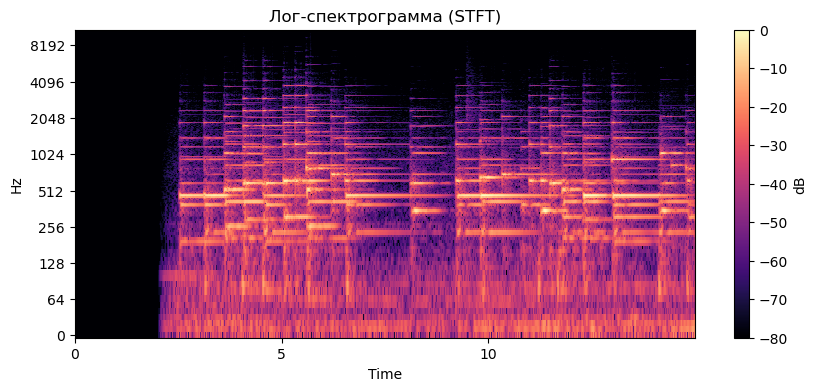

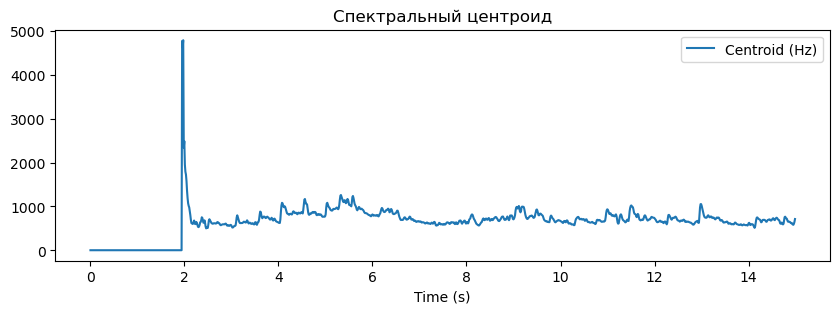

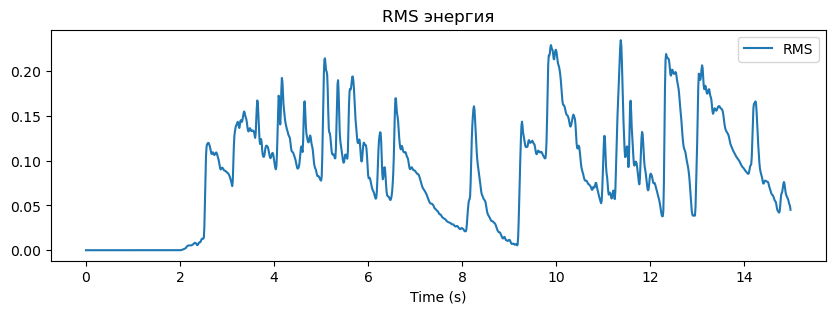

In [15]:
# STFT параметры
n_fft = 2048
hop_length = 256
win = 'hann'

AUDIO_PATH = '../data/1773.wav'
sr_target = 22050
mono = True


# Загрузка и нормировка
y, sr = load_and_downsample_audio(AUDIO_PATH, sr_target, mono=mono)

# STFT
S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window=win))
S_db = librosa.amplitude_to_db(S, ref=np.max)
times = librosa.frames_to_time(np.arange(S_db.shape[1]), sr=sr, hop_length=hop_length)
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

# Центроид и RMS энергия
centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
rms = librosa.feature.rms(S=S)[0]

print("Shapes:", "S_db", S_db.shape, "centroid", centroid.shape, "rms", rms.shape)

plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(label='dB'); plt.title('Лог-спектрограмма (STFT)')
plt.show()

plt.figure(figsize=(10,3))
plt.plot(times, centroid, label='Centroid (Hz)')
plt.xlabel('Time (s)'); plt.title('Спектральный центроид'); plt.legend(); plt.show()

plt.figure(figsize=(10,3))
plt.plot(times, rms, label='RMS')
plt.xlabel('Time (s)'); plt.title('RMS энергия'); plt.legend(); plt.show()

Downsampled by factor 4: 22050 Hz -> 5512 Hz
Loaded: 330750 samples, 60.01 sec, SR: 5512 Hz

[wave]
  τ_AMI = 13  (strategy=first_min, min_lag=5)
  τ_used = 13,  m = 9
  D_box = 2.687, D2 = 1.959


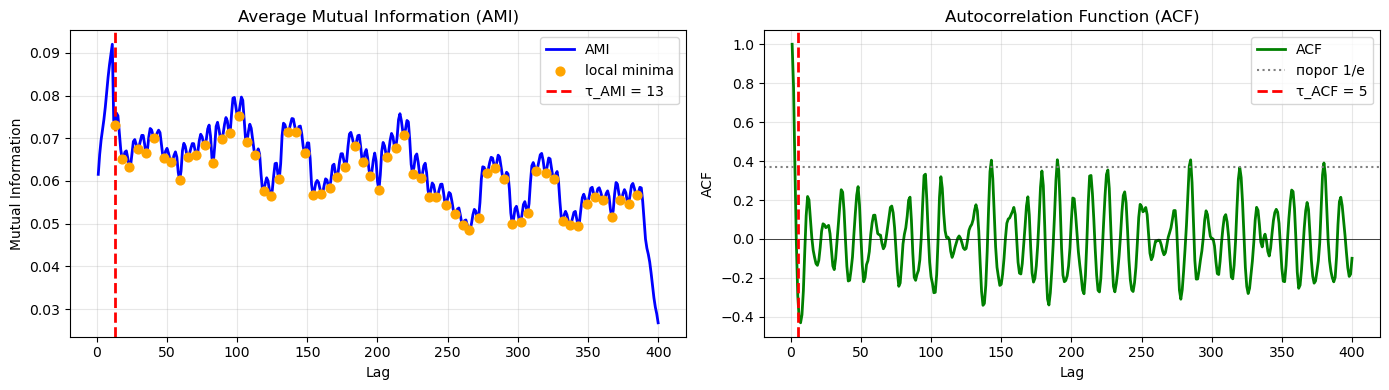

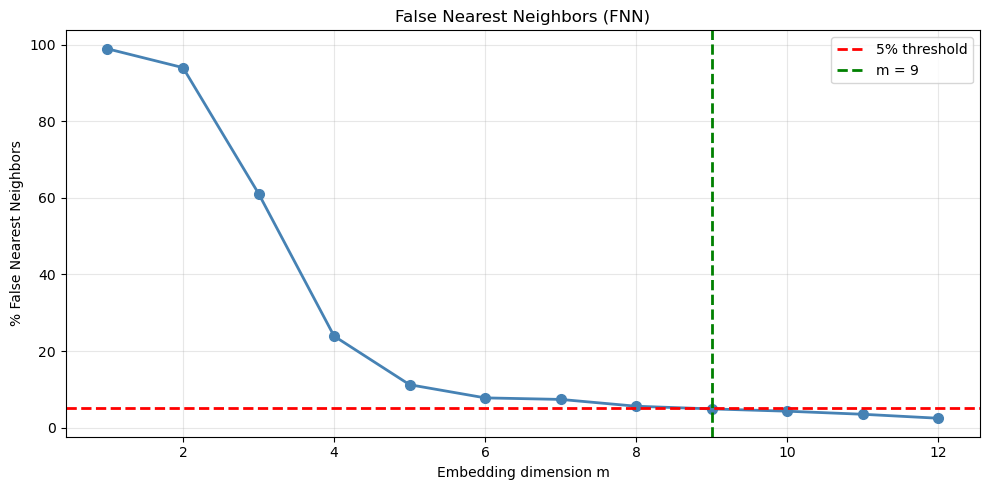

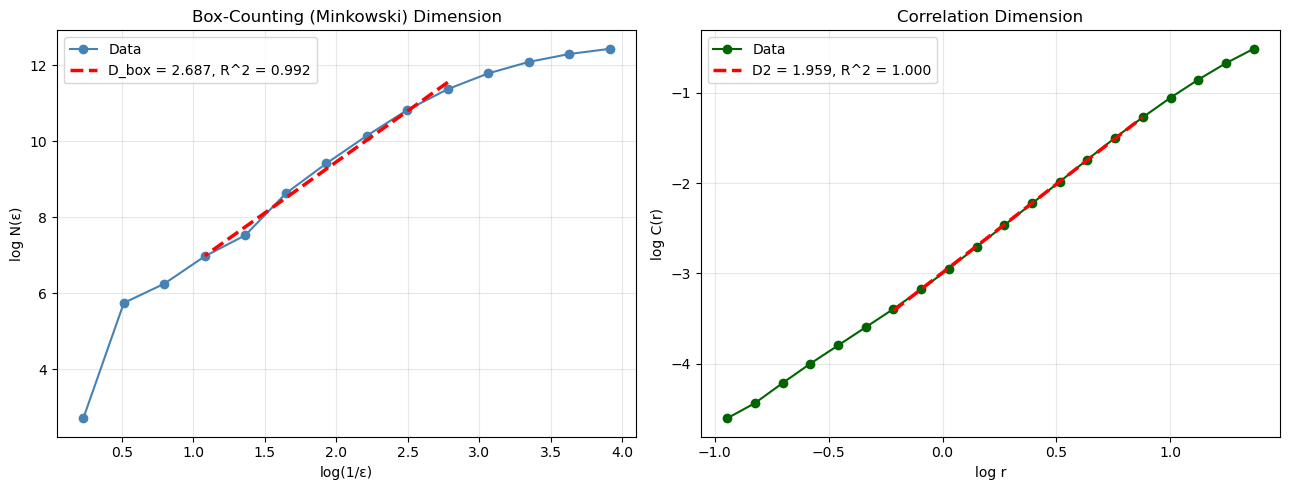

In [16]:
y, sr = load_and_downsample_audio(
    AUDIO_PATH,
    target_sr=22050,
    duration_sec=60.0,
    downsample_factor=4,
)

result, x, Z = fractal_analysis(
    y, sr,
    series_name='wave',
    ami_max_lag=400,
    ami_min_lag=5,
    fnn_m_max=12,
    verbose=True,
)

plot_tau_comparison(result)
plot_fnn_analysis(result)
plot_dimension_fits(result)


In [17]:
y_full, sr_full = load_and_downsample_audio(
    AUDIO_PATH, target_sr=22050, duration_sec=60.0, downsample_factor=1,
)
y_wave, sr_wave = load_and_downsample_audio(
    AUDIO_PATH, target_sr=22050, duration_sec=60.0, downsample_factor=10,
)

print("\nCentroid Analysis")
result_centroid, x_centroid, Z_centroid = fractal_analysis(
    y_full, sr_full,
    series_name='centroid',
    ami_max_lag=400, ami_min_lag=5, fnn_m_max=12, verbose=True,
)

print("\nRMS Analysis")
result_rms, x_rms, Z_rms = fractal_analysis(
    y_full, sr_full,
    series_name='rms',
    ami_max_lag=400, ami_min_lag=5, fnn_m_max=12, verbose=True,
)

print("\nWave Analysis (downsampled)")
result_raw, x_raw, Z_raw = fractal_analysis(
    y_wave, sr_wave,
    series_name='wave',
    ami_max_lag=400, ami_min_lag=5, fnn_m_max=12, verbose=True,
)


Loaded: 1323000 samples, 60.00 sec, SR: 22050 Hz
Downsampled by factor 10: 22050 Hz -> 2205 Hz
Loaded: 132300 samples, 60.00 sec, SR: 2205 Hz

Centroid Analysis

[centroid]
  τ_AMI = 204  (strategy=first_min, min_lag=5)
  τ_used = 204,  m = 4
  D_box = 2.404, D2 = 2.854

RMS Analysis

[rms]
  τ_AMI = 117  (strategy=first_min, min_lag=5)
  τ_used = 117,  m = 4
  D_box = 2.309, D2 = 2.935

Wave Analysis (downsampled)

[wave]
  τ_AMI = 17  (strategy=first_min, min_lag=5)
  τ_used = 17,  m = 9
  D_box = 2.350, D2 = 1.989


- посчитать по всей дорожке (размерность)
- как отличаются размерности отдельных производений и по кускам
- wav представление - попробовать другие представоления с выделением фич (попросить вариации и взять классически известные)
- представление фурье по кусочкам


Centroid Analysis

[centroid]
  τ_AMI = 70  (strategy=first_min, min_lag=5)
  τ_used = 70,  m = 4
  D_box = 1.905, D2 = 3.006

RMS Analysis

[rms]
  τ_AMI = 38  (strategy=first_min, min_lag=5)
  τ_used = 38,  m = 4
  D_box = 1.776, D2 = 2.986

Wave Analysis

[wave]
  τ_AMI = 13  (strategy=first_min, min_lag=5)
  τ_used = 13,  m = 9
  D_box = 2.687, D2 = 1.959

Tau selection comparison (AMI and ACF)

Centroid:


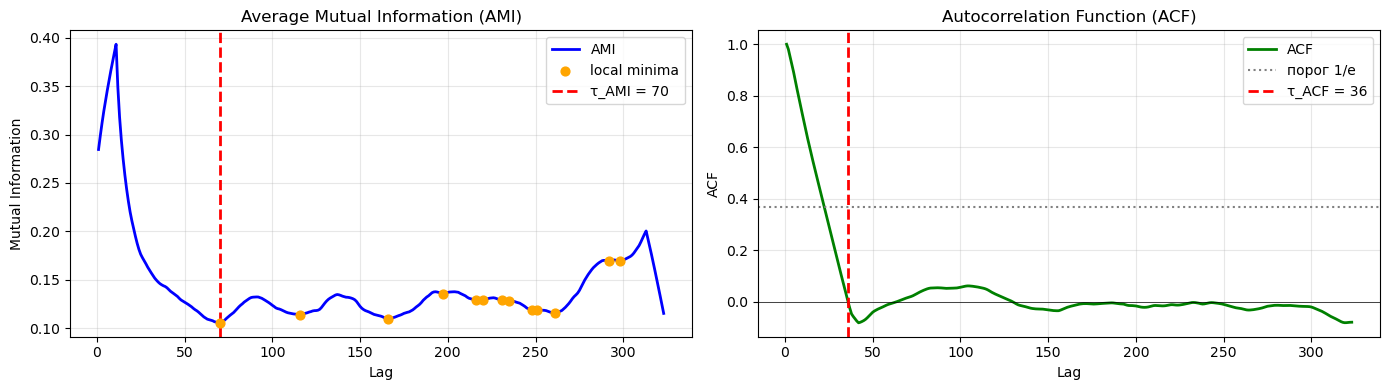


RMS:


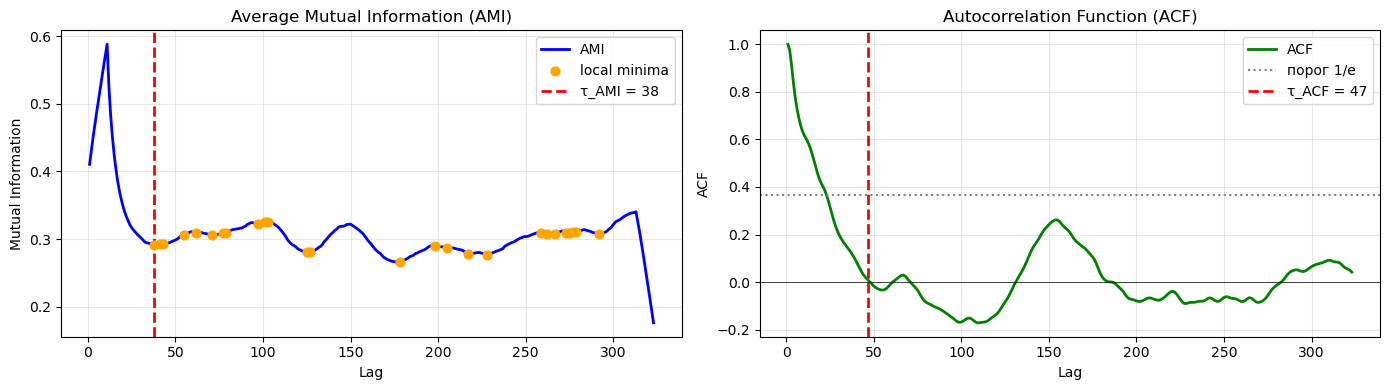


RAW:


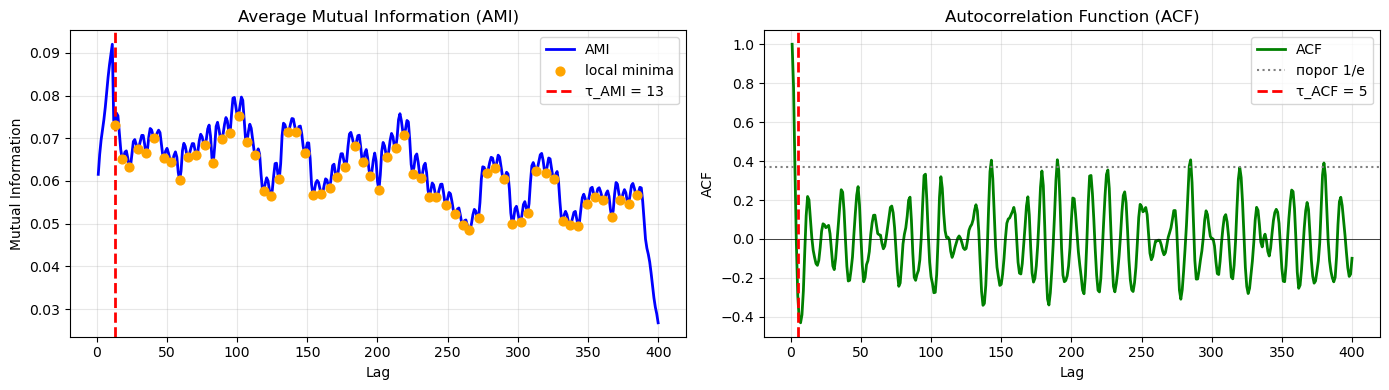


FNN analysis for m selection

Centroid:


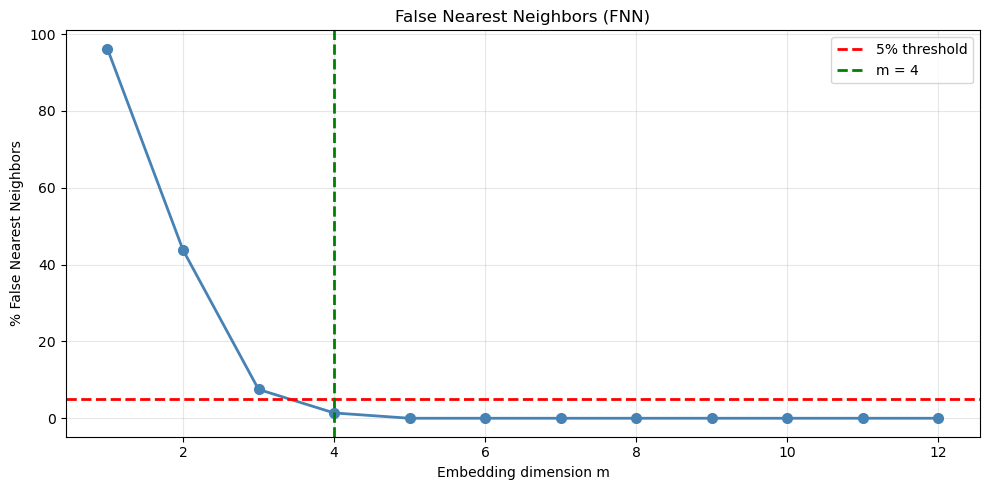


RMS:


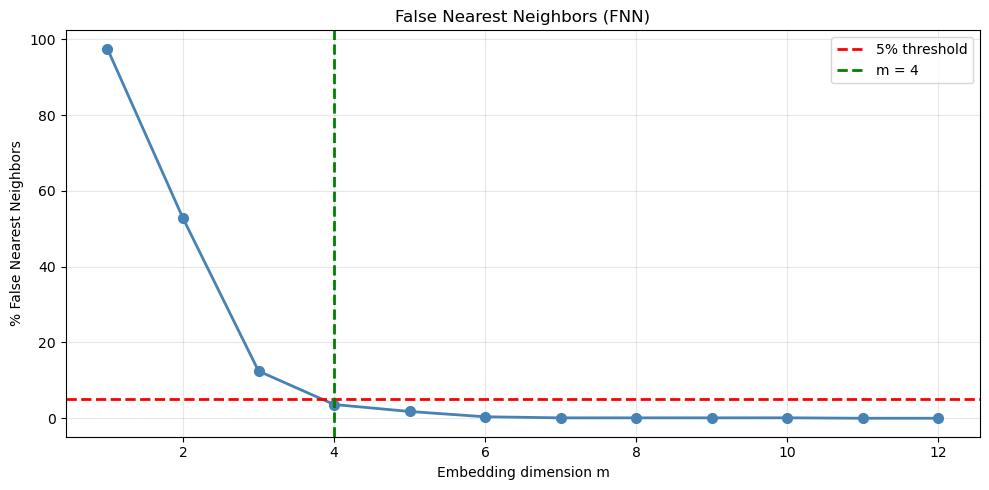


RAW:


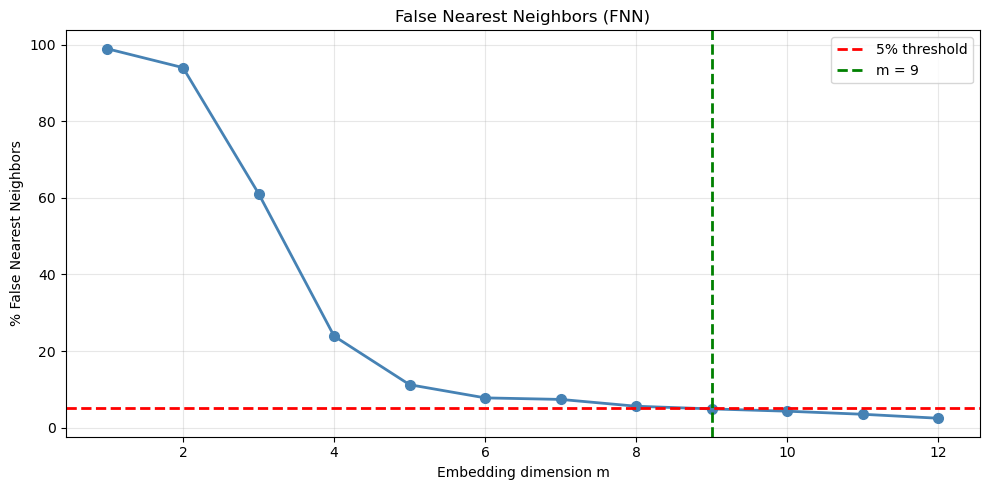


Dimension fits

Centroid:


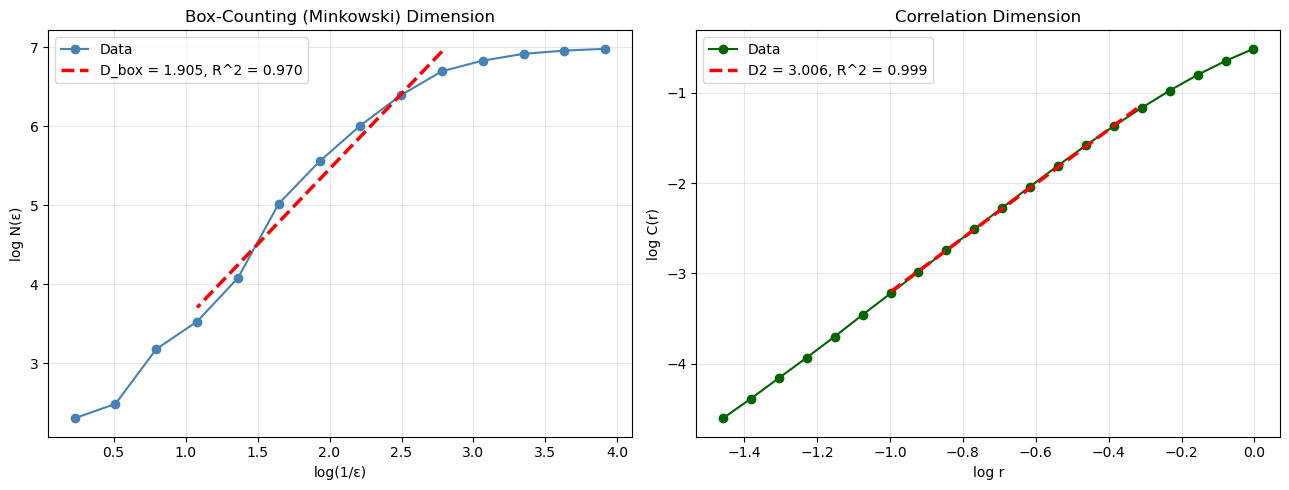


RMS:


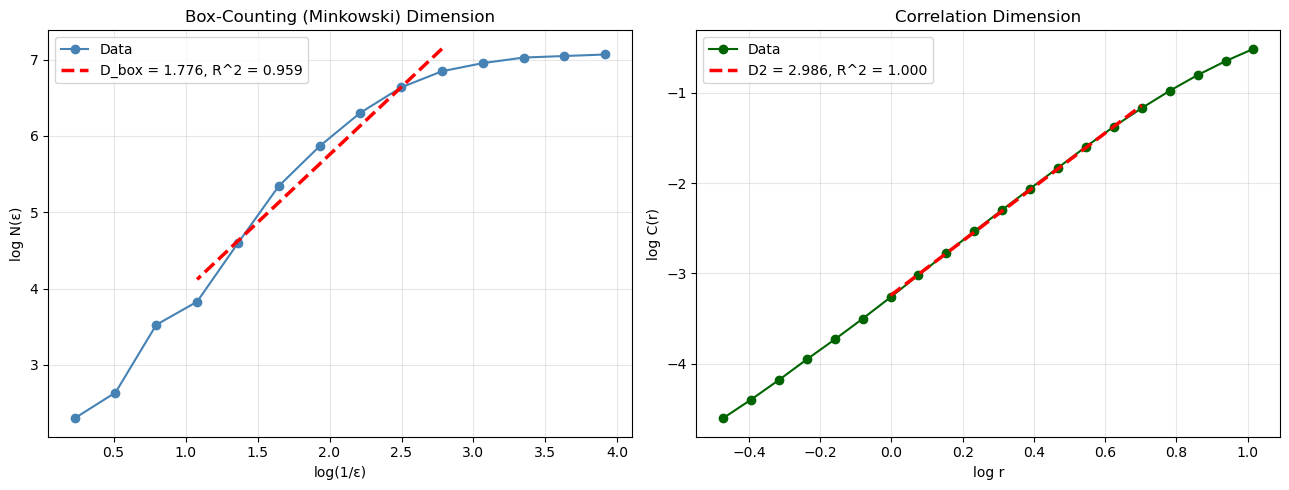


RAW:


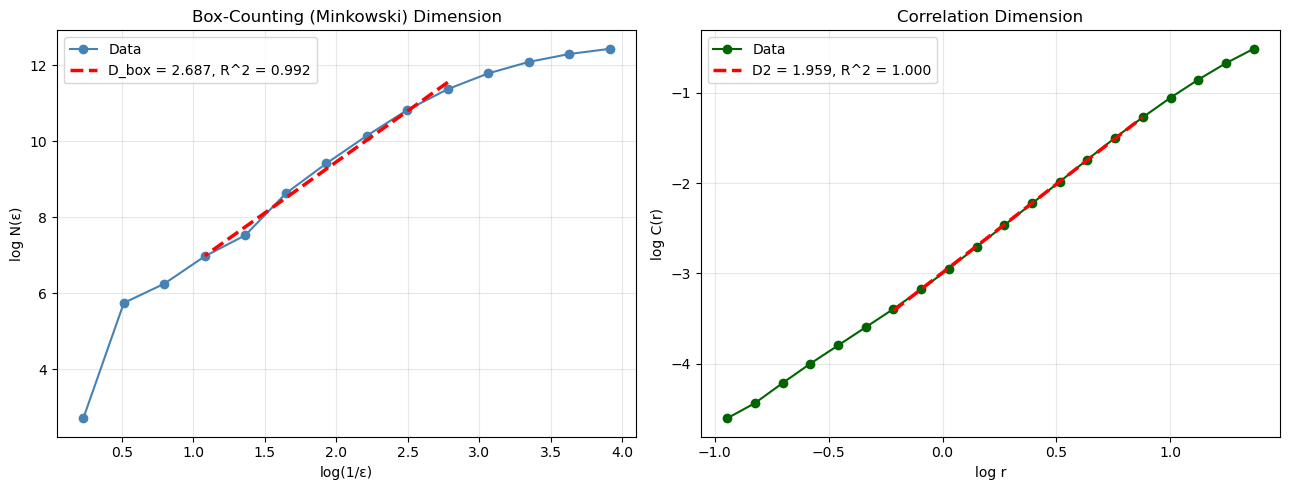


Results:
 Feature  τ_AMI  τ_used  m D_box    D2     Z_shape
Centroid     70      70  4 1.905 3.006   (1082, 4)
     RMS     38      38  4 1.776 2.986   (1178, 4)
     RAW     13      13  9 2.687 1.959 (330646, 9)


In [18]:
print("\nCentroid Analysis")
result_centroid, x_centroid, Z_centroid = fractal_analysis(
    y, sr,
    series_name='centroid',
    ami_max_lag=400, ami_min_lag=5,
    fnn_m_max=12, verbose=True,
)

print("\nRMS Analysis")
result_rms, x_rms, Z_rms = fractal_analysis(
    y, sr,
    series_name='rms',
    ami_max_lag=400, ami_min_lag=5,
    fnn_m_max=12, verbose=True,
)

print("\nWave Analysis")
result_raw, x_raw, Z_raw = fractal_analysis(
    y, sr,
    series_name='wave',
    hop_length=256,
    ami_max_lag=400, ami_min_lag=5,
    fnn_m_max=12, fnn_Rtol=15.0, fnn_Atol=2.0,
    corr_sample_max=3000, seed=0, verbose=True,
)

print("\nTau selection comparison (AMI and ACF)")
print("\nCentroid:"); plot_tau_comparison(result_centroid)
print("\nRMS:");      plot_tau_comparison(result_rms)
print("\nRAW:");      plot_tau_comparison(result_raw)

print("\nFNN analysis for m selection")
print("\nCentroid:"); plot_fnn_analysis(result_centroid)
print("\nRMS:");      plot_fnn_analysis(result_rms)
print("\nRAW:");      plot_fnn_analysis(result_raw)

print("\nDimension fits")
print("\nCentroid:");
plot_dimension_fits(result_centroid)
print("\nRMS:");
plot_dimension_fits(result_rms)
print("\nRAW:");
plot_dimension_fits(result_raw)

print("\nResults:")
summary_data = {
    'Feature': ['Centroid', 'RMS', 'RAW'],
    'τ_AMI':   [result_centroid['tau_ami'],   result_rms['tau_ami'],   result_raw['tau_ami']],
    'τ_used':  [result_centroid['tau_used'],  result_rms['tau_used'],  result_raw['tau_used']],
    'm':       [result_centroid['m'],         result_rms['m'],         result_raw['m']],
    'D_box':   [f"{result_centroid['D_box']:.3f}",   f"{result_rms['D_box']:.3f}",   f"{result_raw['D_box']:.3f}"],
    'D2':      [f"{result_centroid['D2_corr']:.3f}", f"{result_rms['D2_corr']:.3f}", f"{result_raw['D2_corr']:.3f}"],
    'Z_shape': [result_centroid['Z_shape'],   result_rms['Z_shape'],   result_raw['Z_shape']],
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


## 6. Dataset Processing

### 6.1 Embedding Functions

In [19]:
from ripser import ripser
from itertools import combinations

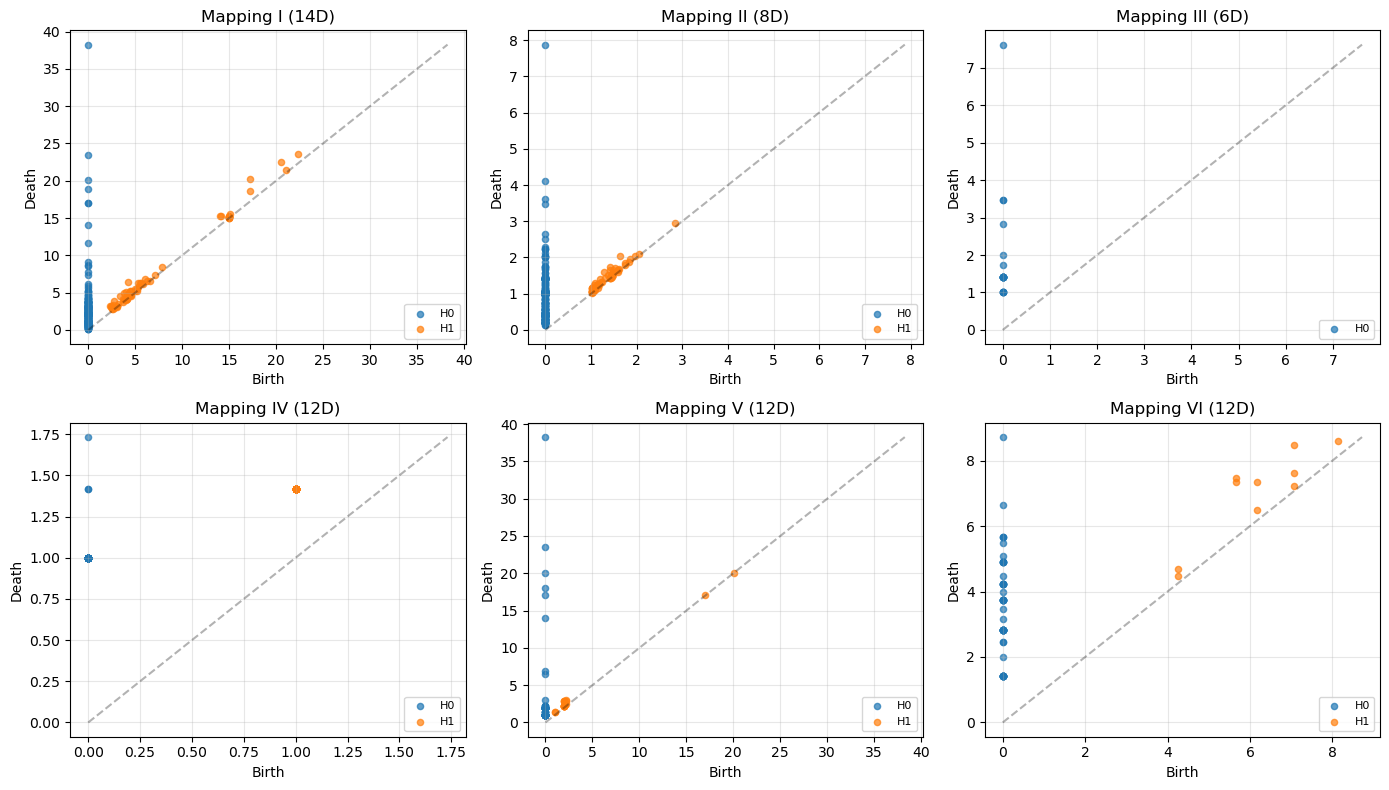

 Map  Dim  H0 bars  H1 bars  H0 max life  H1 max life
   I   14      268       62          inf        2.917
  II    8      268       63          inf        0.408
 III    6       25        0          inf        0.000
  IV   12       71       66          inf        0.414
   V   12       71       19          inf        0.828
  VI   12       62       10          inf        1.826


In [20]:
chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=512)
times = librosa.frames_to_time(np.arange(chroma.shape[1]), sr=sr, hop_length=512)

def chroma_to_events(chroma, times, threshold=0.5):
    events = []
    prev = None
    start = 0
    for i in range(chroma.shape[1]):
        frame = chroma[:, i]
        if np.max(frame) > 0:
            frame = frame / np.max(frame)
        active = tuple(sorted(np.where(frame >= threshold)[0]))
        if len(active) == 0:
            active = (np.argmax(chroma[:, i]),)
        if active != prev:
            if prev is not None:
                events.append({'p': prev, 'onset': start, 'dur': times[i] - start})
            start = times[i]
            prev = active
    if prev:
        events.append({'p': prev, 'onset': start, 'dur': times[-1] - start})
    return events

def interval_vector(pitches):
    iv = [0]*6
    for i, j in combinations(pitches, 2):
        d = abs(j - i) % 12
        if d > 6: d = 12 - d
        if d >= 1: iv[d-1] += 1

    return tuple(iv)

def map_I(events):
    pts = []
    for e in events:
        v = [0]*14
        for i, p in enumerate(e['p'][:12]):
            v[i] = p + 12
        v[12], v[13] = e['dur'], e['onset']
        pts.append(v)
    return np.array(pts, float)

def map_II(events):
    return np.array([list(interval_vector(e['p'])) + [e['dur'], e['onset']] for e in events], float)

def map_III(events):
    return np.array([interval_vector(e['p']) for e in events], float)

def map_IV(events):
    pts = []
    for e in events:
        v = [0]*12
        for p in e['p']:
            v[p % 12] = 1
        pts.append(v)
    return np.array(pts, float)

def map_V(events):
    pts = []
    for e in events:
        v = [0]*12
        for i, p in enumerate(e['p'][:12]):
            v[i] = p + 12
        pts.append(v)
    return np.array(pts, float)

def map_VI(events):
    pts = []
    for e in events:
        v = [0]*12
        p = sorted(e['p'])
        for i, pc in enumerate(p):
            nxt = p[(i+1) % len(p)]
            v[pc % 12] = (nxt - pc) % 12
        pts.append(v)
    return np.array(pts, float)

events = chroma_to_events(chroma, times, threshold=0.5)

mappings = {'I': map_I, 'II': map_II, 'III': map_III, 'IV': map_IV, 'V': map_V, 'VI': map_VI}
results = {}
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (name, func) in enumerate(mappings.items()):
    pts = func(events)
    dgm = ripser(pts, maxdim=1)['dgms']
    results[name] = {'pts': pts, 'dgms': dgm}

    ax = axes[idx]
    for dim, d in enumerate(dgm):
        if len(d) > 0:
            fin = d[np.isfinite(d[:,1])]
            if len(fin) > 0:
                ax.scatter(fin[:,0], fin[:,1], label=f'H{dim}', alpha=0.7, s=20)
    mx = max([np.max(d[np.isfinite(d[:,1])]) for d in dgm if len(d) > 0 and np.any(np.isfinite(d[:,1]))] + [1])
    ax.plot([0, mx], [0, mx], 'k--', alpha=0.3)
    ax.set_title(f'Mapping {name} ({pts.shape[1]}D)')
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Map':>4} {'Dim':>4} {'H0 bars':>8} {'H1 bars':>8} {'H0 max life':>12} {'H1 max life':>12}")
for name, r in results.items():
    h0, h1 = r['dgms'][0], r['dgms'][1] if len(r['dgms']) > 1 else np.array([])
    h0_life = np.max(h0[:,1] - h0[:,0]) if len(h0) > 0 and np.any(np.isfinite(h0[:,1])) else 0
    h1_fin = h1[np.isfinite(h1[:,1])] if len(h1) > 0 else np.array([]).reshape(0,2)
    h1_life = np.max(h1_fin[:,1] - h1_fin[:,0]) if len(h1_fin) > 0 else 0
    print(f"{name:>4} {r['pts'].shape[1]:>4} {len(h0):>8} {len(h1_fin):>8} {h0_life:>12.3f} {h1_life:>12.3f}")


In [21]:
import soundfile as sf

from pathlib import Path
from typing import List, Dict, Optional, Tuple
from sklearn.decomposition import PCA

from joblib import Parallel, delayed
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class MusicNetLoader:
    def __init__(self, base_path: str = '../data/dataset_archive/musicnet/musicnet'):
        self.base_path = Path(base_path)
        self.train_path = self.base_path / 'train_data'
        self.test_path = self.base_path / 'test_data'

    def list_tracks(self, split: str = 'train') -> List[str]:
        path = self.train_path if split == 'train' else self.test_path
        if not path.exists():
            raise FileNotFoundError(f"Path {path} not found")

        return sorted([f.stem for f in path.glob('*.wav')])

    def load_track(self, track_name: str, split: str = 'train', sr: int = 22050, duration: Optional[float] = None) -> Tuple[np.ndarray, int]:
        wav_path = (self.train_path if split == 'train' else self.test_path) / f"{track_name}.wav"


        if not wav_path.exists():
            raise FileNotFoundError(f"Track {track_name} not found in {split}")

        y, sr_loaded = librosa.load(wav_path, sr=sr, mono=True, duration=duration)

        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))

        return y, sr_loaded

    def get_track_info(self, track_id: str, split: str = 'train') -> Dict:
        path = self.train_path if split == 'train' else self.test_path
        wav_path = path / f"{track_id}.wav"

        if not wav_path.exists():
            return {'exists': False}

        info = sf.info(str(wav_path))

        return {
            'exists': True,
            'duration': info.duration,
            'samplerate': info.samplerate,
            'channels': info.channels,
            'path': str(wav_path)
        }

In [33]:
def get_all_embeddings(y, sr, hop=256):
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop))
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop)
    events = chroma_to_events(chroma, librosa.frames_to_time(np.arange(chroma.shape[1]), sr=sr, hop_length=hop))

    # Mel-спектрограмма с меньшей размерностью (20 бинов × 3 фрейма = 60D)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=20, hop_length=hop)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)
    n_frames = 3
    n_total = mel_db.shape[1]
    if n_total >= n_frames:
        mel_emb = np.zeros((n_total - n_frames + 1, 20 * n_frames))
        for i in range(n_total - n_frames + 1):
            mel_emb[i] = mel_db[:, i:i+n_frames].flatten()
    else:
        mel_emb = mel_db.T

    return {
        'wave': resample(y, len(y)//10),
        'centroid': librosa.feature.spectral_centroid(S=S, sr=sr)[0],
        'rms': librosa.feature.rms(S=S)[0],
        'mfcc1': librosa.feature.mfcc(S=librosa.power_to_db(S**2), sr=sr, n_mfcc=13)[1],
        'bandwidth': librosa.feature.spectral_bandwidth(S=S, sr=sr)[0],
        'zcr': librosa.feature.zero_crossing_rate(y, hop_length=hop)[0],
        'map_I': map_I(events),
        'map_II': map_II(events),
        'map_III': map_III(events),
        'map_IV': map_IV(events),
        'map_V': map_V(events),
        'map_VI': map_VI(events),
        'mel_spec': mel_emb,
    }

def analyze_track_all_embeddings(y, sr):
    embs = get_all_embeddings(y, sr)
    rows = []

    for name, data in embs.items():
        if data.ndim == 1:
            x = z_normalize(data)
            max_lag = min(400, len(x)//4)
            if max_lag < 10:
                rows.append({'emb': name, 'tau': np.nan, 'm': np.nan, 'D_box': np.nan, 'D2': np.nan, 'n': len(data)})
                continue

            _, tau, _ = average_mutual_information(x, max_lag=max_lag)
            tau = max(tau, 5)  # минимум 5 для лучшего разделения
            FNN = false_nearest_neighbors(x, tau, m_max=12)
            m = int(np.where(FNN < 5)[0][0] + 1) if np.any(FNN < 5) else int(np.argmin(FNN) + 1)
            Z = delay_embed(x, m, tau)
        else:
            # Многомерные данные (маппинги, спектрограмма)
            tau, m = 0, data.shape[1]

            if len(np.unique(data)) <= 2:
                rows.append({'emb': name, 'tau': 0, 'm': m, 'D_box': np.nan, 'D2': np.nan, 'n': len(data)})
                continue

            data_norm = (data - data.mean(axis=0)) / (data.std(axis=0) + 1e-8)
            data_norm += np.random.randn(*data_norm.shape) * 0.02

            if name.startswith('map_') or name == 'mel_spec':
                target_dim = min(4, data.shape[1], len(data) - 1)
                pca = PCA(n_components=target_dim)
                Z = pca.fit_transform(data_norm)
                m = target_dim
            else:
                Z = data_norm

        # threshold для размерности
        if len(Z) < 300:
            rows.append({'emb': name, 'tau': tau, 'm': m, 'D_box': np.nan, 'D2': np.nan, 'n': len(Z)})
            continue

        D_box, info_box = box_counting_dimension(Z)
        D2, info_corr = correlation_dimension(Z, sample_max=min(3000, len(Z)))

        if info_box.get('r2', 0) < 0.9:
            D_box = np.nan
        if info_corr.get('r2', 0) < 0.9:
            D2 = np.nan

        rows.append({'emb': name, 'tau': tau, 'm': m, 'D_box': D_box, 'D2': D2, 'n': len(Z)})

    return pd.DataFrame(rows)


In [23]:
def analyze_single_track(track_id: str, split: str, base_path: str):
    try:
        local_loader = MusicNetLoader(base_path)
        y, sr = local_loader.load_track(track_id, split)

        df = analyze_track_all_embeddings(y, sr)
        df['track'] = track_id

        return df
    except Exception as e:
        import traceback
        traceback.print_exc()
        raise

def compare_tracks_parallel(loader, track_ids, split='train', n_jobs=10):
    base_path = str(loader.base_path)

    results = Parallel(n_jobs=n_jobs, verbose=10, backend='loky')(
        delayed(analyze_single_track)(tid, split, base_path)
        for tid in tqdm(track_ids, desc=f"Scheduling {len(track_ids)} tracks")
    )

    valid_results = [r for r in results if r is not None]

    if not valid_results:
        print("No valid results!")
        return pd.DataFrame()

    df = pd.concat(valid_results, ignore_index=True)
    return df


In [24]:
import seaborn as sns

def plot_results(df, max_tracks=10):
    df_valid = df[df['D_box'].notna() & (df['D_box'] > 0.5)]

    _, ax = plt.subplots(1, 2, figsize=(14, 5))

    tracks = df_valid['track'].unique()[:max_tracks]
    for track in tracks:
        d = df_valid[df_valid['track'] == track]
        ax[0].bar(d['emb'], d['D_box'], alpha=0.5, label=track)
        ax[1].bar(d['emb'], d['D2'], alpha=0.5, label=track)

    ax[0].set_ylabel('D_box'); ax[0].set_title('Box-Counting Dimension')
    ax[1].set_ylabel('D2'); ax[1].set_title('Correlation Dimension')
    for a in ax:
        a.tick_params(axis='x', rotation=45)
        a.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df, figsize=(10, 8)):
    pivot = df.pivot_table(index='track', columns='emb', values='D_box')
    corr = pivot.corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
                square=True, linewidths=0.5)
    plt.title('Embedings D_box correlation')
    plt.tight_layout()
    plt.show()

def visualize_boxplot(df):
    emb_order = ['wave', 'centroid', 'rms', 'mfcc1', 'bandwidth', 'zcr',
                 'map_I', 'map_II', 'map_III', 'map_V', 'map_VI']
    emb_order = [e for e in emb_order if e in df['emb'].unique()]

    df_valid = df[df['D_box'].notna()].copy()

    # Boxplot
    _, ax = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=df_valid, x='emb', y='D_box', order=emb_order, ax=ax[0], palette='Set2')
    sns.boxplot(data=df[df['D2'].notna()], x='emb', y='D2', order=emb_order, ax=ax[1], palette='Set2')
    for a in ax:
        a.set_xticklabels(a.get_xticklabels(), rotation=45, ha='right')
        a.grid(True, alpha=0.3, axis='y')
    ax[0].set_title('D_box'); ax[1].set_title('D2')
    plt.tight_layout(); plt.show()

    # Сводка
    summary = df.groupby('emb')[['D_box', 'D2']].agg(['mean', 'std', 'count']).round(3)
    print(summary)

### 6.2 Parallel Analysis

Scheduling 10 tracks: 100%|██████████| 10/10 [00:00<00:00, 114.86it/s]
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:   25.5s remaining:   59.4s
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:   28.1s remaining:   28.1s
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:   30.7s remaining:   13.1s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   36.6s finished


Results:
      emb  tau  m    D_box       D2      n track
     wave   11  9 2.411727 2.454851 429147  1759
 centroid    5  5 1.277280 2.725636  16748  1759
      rms  313  5 2.629326 3.793924  15516  1759
    mfcc1  164  5 2.363919 3.849325  16112  1759
bandwidth   18  5 1.866029 3.595525  16696  1759
      zcr  210  5 2.423594 3.740787  15928  1759
    map_I    0  4 1.537523 2.029236   3077  1759
   map_II    0  4 2.145355 2.582318   3077  1759
  map_III    0  4 1.208235      NaN   3077  1759
   map_IV    0 12      NaN      NaN   3077  1759
    map_V    0  4 1.251856 1.361055   3077  1759
   map_VI    0  4 1.619541      NaN   3077  1759
 mel_spec    0  4 2.300031 2.278587  16766  1759
     wave    5  6 2.801188 1.668073 391309  1819
 centroid  322  5 2.561156 3.618873  13999  1819
      rms   26  5 2.375018 3.590569  15183  1819
    mfcc1   27  4 2.620312 3.220095  15206  1819
bandwidth   91  5 2.081893 3.308537  14923  1819
      zcr   81  5 2.254512 3.822624  14963  1819
    map_I  

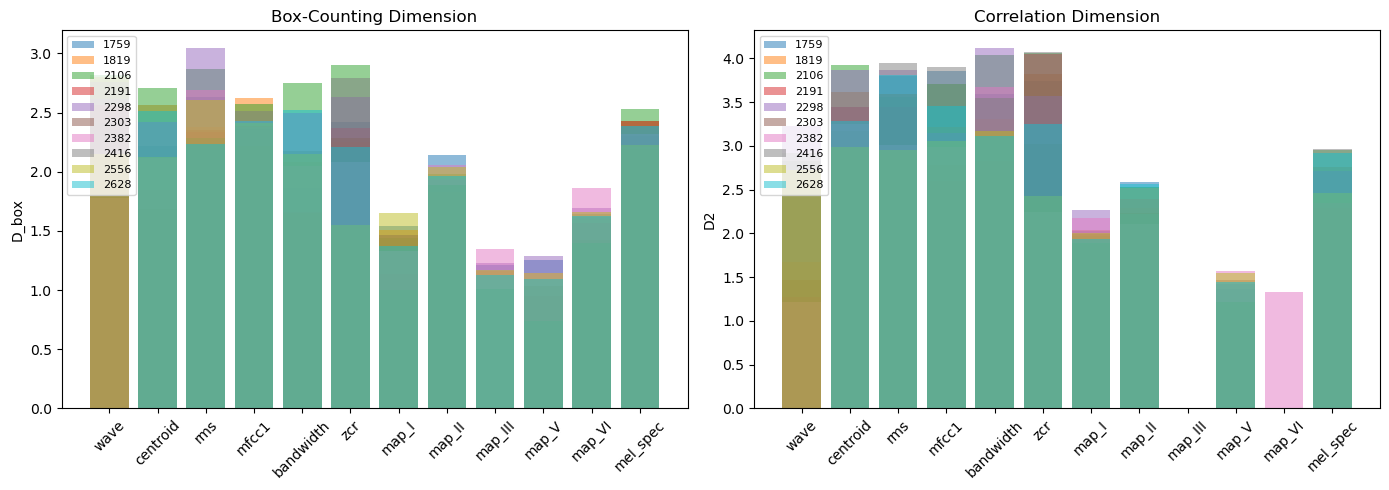

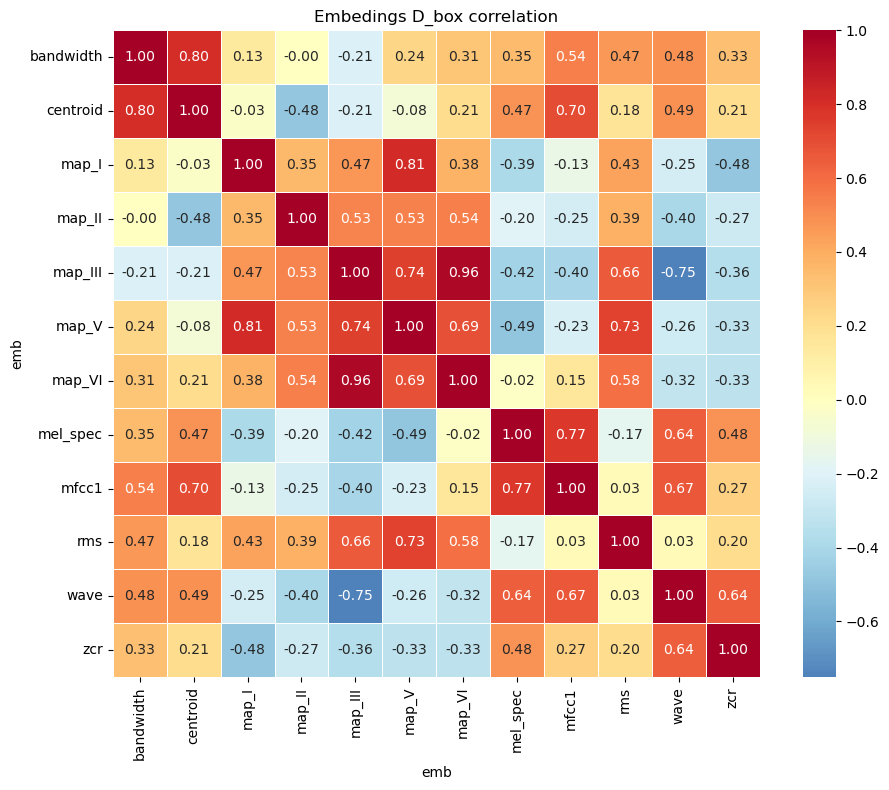

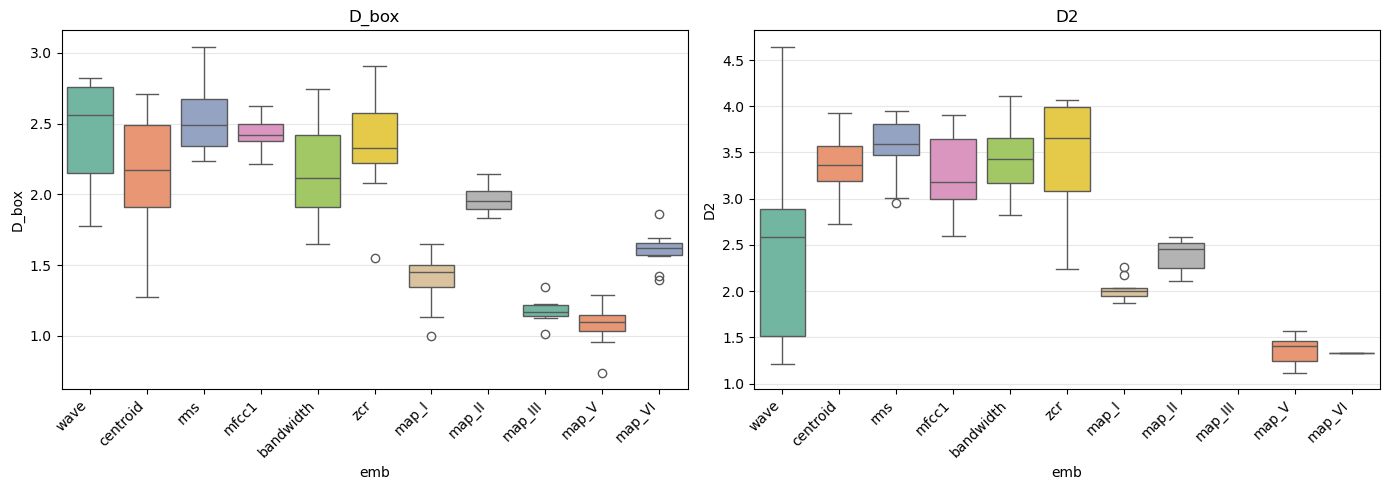

           D_box                  D2             
            mean    std count   mean    std count
emb                                              
bandwidth  2.140  0.366    10  3.455  0.415    10
centroid   2.146  0.443    10  3.371  0.372    10
map_I      1.392  0.193    10  2.016  0.122    10
map_II     1.965  0.093    10  2.395  0.171    10
map_III    1.179  0.101     7    NaN    NaN     0
map_IV       NaN    NaN     0    NaN    NaN     0
map_V      1.083  0.163     9  1.373  0.149    10
map_VI     1.609  0.131    10  1.330    NaN     1
mel_spec   2.340  0.110    10  2.602  0.287    10
mfcc1      2.433  0.115    10  3.269  0.447    10
rms        2.542  0.271    10  3.557  0.341    10
wave       2.423  0.390     9  2.442  1.072    10
zcr        2.349  0.385    10  3.424  0.674    10


In [ ]:
loader = MusicNetLoader()
tracks = loader.list_tracks('test')
df_test = compare_tracks_parallel(loader, tracks, split='test')

print("Results:")
print(df_test.to_string(index=False))
plot_results(df_test)
plot_correlation_heatmap(df_test)
visualize_boxplot(df_test)

Scheduling 320 tracks:   9%|▉         | 30/320 [02:26<25:51,  5.35s/it][Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:  2.6min
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:  4.1min
Scheduling 320 tracks: 100%|██████████| 320/320 [40:30<00:00,  7.60s/it]
[Parallel(n_jobs=10)]: Done 320 out of 320 | elapsed: 43.7min finished


Results:
      emb  tau  m    D_box       D2       n track
     wave    6 12 2.699759 4.296978  985700  1727
 centroid   74  5 2.354445 3.927541   38211  1727
      rms   32  5 2.788395 3.438869   38379  1727
    mfcc1   35  5 2.800355 3.853201   38367  1727
bandwidth   75  5 2.385258 4.041900   38207  1727
      zcr   75  5 2.031327 3.767490   38207  1727
    map_I    0  4 0.934215 2.074813    4920  1727
   map_II    0  4 1.892317 2.418928    4920  1727
  map_III    0  4      NaN      NaN    4920  1727
   map_IV    0 12      NaN      NaN    4920  1727
    map_V    0  4 1.024648 1.522397    4920  1727
   map_VI    0  4 1.761199      NaN    4920  1727
 mel_spec    0  4 2.588288 3.150633   38505  1727
     wave    6 12 2.473181 2.881061  553700  1728
 centroid   11  5 1.764646 3.675500   21588  1728
      rms   40  5 2.879272 2.607147   21472  1728
    mfcc1   27  5 2.678762 3.756356   21524  1728
bandwidth   40  5 2.257537 4.036496   21472  1728
      zcr   40  5 1.986452 3.802590   214

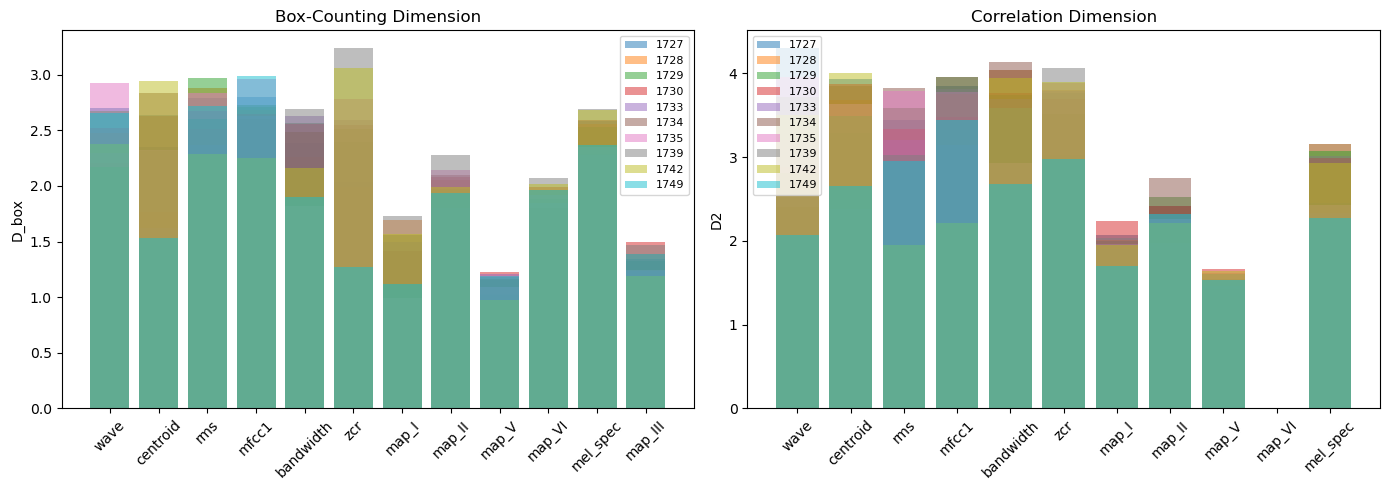

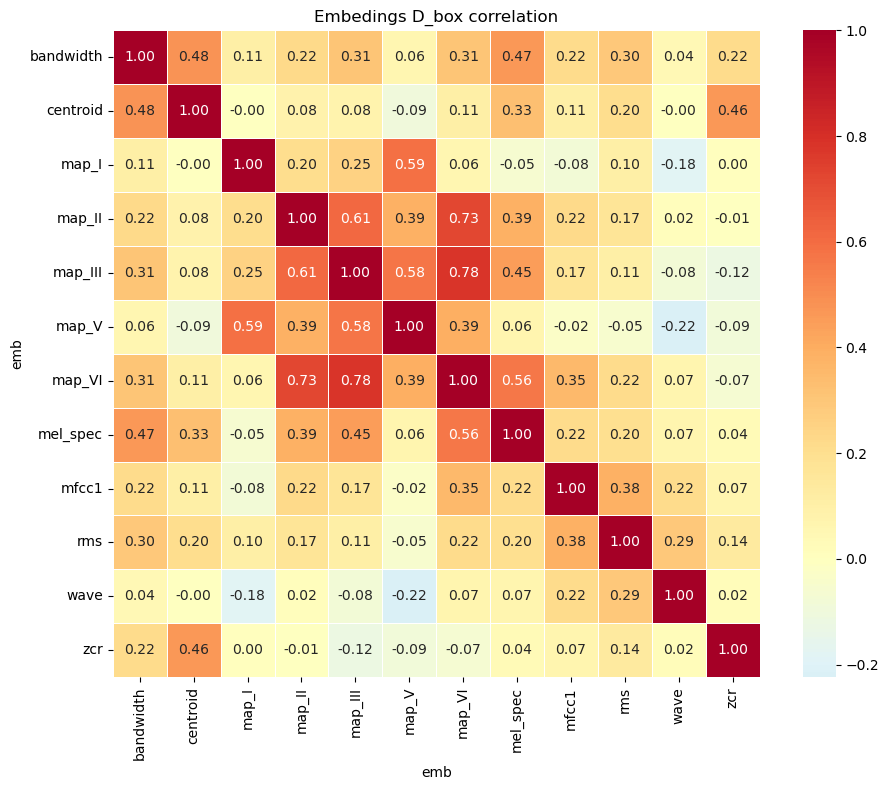

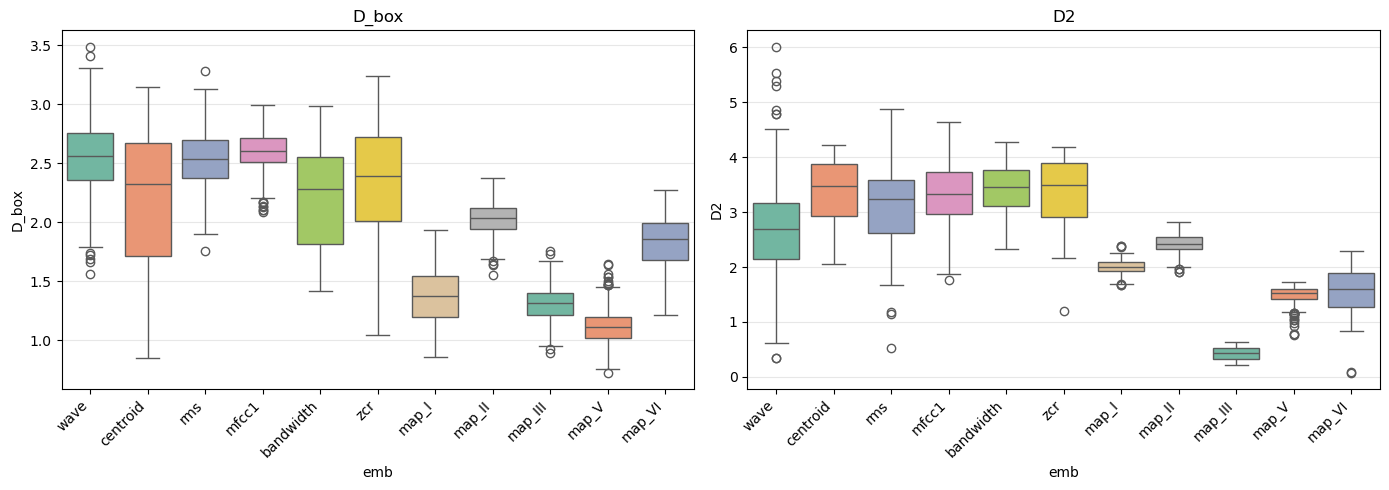

           D_box                  D2             
            mean    std count   mean    std count
emb                                              
bandwidth  2.214  0.414   320  3.431  0.425   320
centroid   2.205  0.558   319  3.394  0.532   320
map_I      1.376  0.219   318  2.006  0.121   320
map_II     2.028  0.138   320  2.427  0.174   320
map_III    1.314  0.151   277  0.426  0.306     2
map_IV       NaN    NaN     0    NaN    NaN     0
map_V      1.124  0.156   300  1.487  0.157   320
map_VI     1.829  0.211   320  1.474  0.576    24
mel_spec   2.318  0.239   320  2.636  0.334   320
mfcc1      2.596  0.178   320  3.314  0.498   320
rms        2.544  0.237   318  3.126  0.669   320
wave       2.554  0.308   318  2.673  0.814   320
zcr        2.326  0.518   320  3.401  0.554   320


In [ ]:
# train -> большой датасет
loader = MusicNetLoader()
tracks = loader.list_tracks('train')
df_train = compare_tracks_parallel(loader, tracks, split='train')

print("Results:")
print(df_train.to_string(index=False))
plot_results(df_train)
plot_correlation_heatmap(df_train)
visualize_boxplot(df_train)

## Описание эмбеддингов

### 1D временные ряды (спектральные признаки)

| Эмбеддинг | Что измеряет | Физический смысл | Для чего хорош |
|-----------|--------------|------------------|----------------|
| **wave** | Сырой аудиосигнал (downsampled) | Амплитуда звуковой волны во времени | Базовый эмбеддинг, отражает полную динамику сигнала. Высокая размерность из-за высокой частоты дискретизации |
| **centroid** | Спектральный центроид | "Центр масс" спектра — средневзвешенная частота. Высокий = яркий звук, низкий = глухой | Отражает тембр и "яркость" звука. Хорошо различает инструменты |
| **rms** | Root Mean Square энергия | Громкость сигнала в каждом фрейме | Динамика произведения: тихие/громкие части, крещендо, диминуэндо |
| **mfcc1** | 1-й мел-кепстральный коэффициент | Общая форма спектральной огибающей | Тембральные характеристики, используется в распознавании речи и музыки |
| **bandwidth** | Спектральная ширина полосы | Разброс частот вокруг центроида | Насыщенность звука: узкая полоса = чистый тон, широкая = шум или богатый тембр |
| **zcr** | Zero Crossing Rate | Частота пересечения нуля сигналом | Перкуссивность и шумность. Высокий ZCR = шипящие звуки, ударные |

### Многомерные эмбеддинги (TDA маппинги)

| Эмбеддинг | Размерность | Что кодирует | Физический смысл |
|-----------|-------------|--------------|------------------|
| **map_I** | 14D | Питчи + длительность + время начала | Полная информация о нотных событиях: какие ноты, когда, как долго |
| **map_II** | 8D | Интервальный вектор + длительность + время | Гармоническая структура аккордов (какие интервалы между нотами) |
| **map_III** | 6D | Только интервальный вектор | Чистая гармония без временной информации. Классификация аккордов |
| **map_IV** | 12D | Бинарный pitch-class вектор | Какие из 12 нот хроматической гаммы звучат (0/1). Бинарные данные |
| **map_V** | 12D | Питчи без временной информации | Мелодическая линия: какие ноты звучат |
| **map_VI** | 12D | Интервалы между соседними нотами | Мелодическое движение: на сколько полутонов переход между нотами |

### Спектрограммный эмбеддинг

| Эмбеддинг | Размерность | Что кодирует | Физический смысл |
|-----------|-------------|--------------|------------------|
| **mel_spec** | 60D (20×3) | Скользящее окно по мел-спектрограмме | Локальная спектральная структура во времени. Комбинация частотной и временной информации |

## Интерпретация результатов

| D_box / D2 | Интерпретация |
|------------|---------------|
| ~1.0-1.5 | Простая структура, близкая к линии или кривой |
| ~1.5-2.0 | Умеренная сложность, типично для музыкальных сигналов |
| ~2.0-2.5 | Высокая сложность, богатая динамика |
| ~2.5-3.0 | Очень сложная структура, близкая к заполнению пространства |

Для классической музыки типичные значения:
- **D_box**: 1.8-2.6
- **D2**: 1.2-2.0

In [34]:
fractals = {
    'Cantor set':           (cantor_set(),            np.log(2)/np.log(3)),
    'Koch curve':           (koch_curve(),            np.log(4)/np.log(3)),
    'Sierpinski triangle':  (sierpinski_triangle(),   np.log(3)/np.log(2)),
    'Sierpinski carpet':    (sierpinski_carpet(),     np.log(8)/np.log(3)),
}

print(f"{'Фрактал':<24} {'D_theory':>7} {'D_box':>7} {'D_corr':>7}  {'delta_box':>6} {'delta_corr':>6}\n")

for name, (pts, D_true) in fractals.items():
    D_box,  _ = box_counting_dimension(pts)
    D_corr, _ = correlation_dimension(pts)
    err_b = abs(D_box  - D_true) if not np.isnan(D_box)  else float('nan')
    err_c = abs(D_corr - D_true) if not np.isnan(D_corr) else float('nan')
    print(f"{name:<24} {D_true:7.4f} {D_box:7.4f} {D_corr:7.4f}  {err_b:6.4f} {err_c:6.4f}")


Фрактал                  D_theory   D_box  D_corr  delta_box delta_corr

Cantor set                0.6309  0.7814  0.6275  0.1505 0.0034
Koch curve                1.2619  1.5363  1.2219  0.2744 0.0399
Sierpinski triangle       1.5850  1.6697  1.5323  0.0847 0.0526
Sierpinski carpet         1.8928  1.9920  1.6842  0.0992 0.2086


In [27]:
fractals_schw = {
    'Cantor set':          (cantor_set(),            np.log(2)/np.log(3)),
    'Koch curve':          (koch_curve(),            np.log(4)/np.log(3)),
    'Sierpinski triangle': (sierpinski_triangle(),   np.log(3)/np.log(2)),
    'Sierpinski carpet':   (sierpinski_carpet(),     np.log(8)/np.log(3)),
}

print("Алгоритм Швайнхарта (размерность Хаусдорфа)")
print(f"{'Фрактал':<24} {'D_true':>7} {'D_schw':>7} {'delta':>7}")

for name, (pts, D_true) in fractals_schw.items():
    res = schweinhart_dimension(
        pts,
        alphas=np.arange(0.3, min(D_true + 1.5, 5.0), 0.3),
        sample_sizes=np.unique(np.geomspace(50, min(len(pts), 2000), num=7).astype(int))
    )
    d_est = res['median_d']
    err = abs(d_est - D_true)
    print(f"{name:<24} {D_true:7.4f} {d_est:7.4f} {err:7.4f}")

print()
print("Алгоритм Брито (топологическая размерность)")
print(f"{'Фрактал':<24} {'d_T ожид':>8} {'d_Brito':>8} {'E[d]':>8}")

# Брито работает только для целочисленных размерностей (многообразия)
for name, (pts, D_true) in fractals_schw.items():
    d_T_expected = int(round(D_true))
    n = min(len(pts), 800)
    res = brito_dimension(pts[:n], max_dim=5, K=30, sample_size=min(400, n))
    print(f"{name:<24} {d_T_expected:>8d} {res['d_brito']:>8d} {res['d_expected']:>8.2f}")


Алгоритм Швайнхарта (размерность Хаусдорфа)
Фрактал                   D_true  D_schw   delta
Cantor set                0.6309  0.5918  0.0391
Koch curve                1.2619  1.2764  0.0146
Sierpinski triangle       1.5850  1.5847  0.0003
Sierpinski carpet         1.8928  1.8449  0.0479

Алгоритм Брито (топологическая размерность)
Фрактал                  d_T ожид  d_Brito     E[d]
Cantor set                      1        5     5.00
Koch curve                      1        2     2.00
Sierpinski triangle             2        2     2.00
Sierpinski carpet               2        2     2.02


- убрать брито
- сначала валидацию на фракталах и многомерных пространствах
- потом про музыку все вычисления
- переносим в отчёт, скинуть на чек

In [26]:
y, sr = load_and_downsample_audio(
    AUDIO_PATH, target_sr=22050, duration_sec=30.0, downsample_factor=4,
)

for sname in ['wave', 'centroid', 'rms']:
    print(f"Эмбед: {sname}")

    try:
        result, x, Z = fractal_analysis(
            y, sr, series_name=sname,
            ami_max_lag=400,
            ami_min_lag=5,
            fnn_m_max=8,
            verbose=True
        )
    except ValueError as e:
        continue

    n_pts = Z.shape[0]

    res_schw = schweinhart_dimension(
        Z,
        alphas=np.arange(0.2, 4.0, 0.3),
        sample_sizes=np.unique(np.geomspace(50, min(n_pts, 2000), num=8).astype(int))
    )
    print(f"D_Schweinhart = {res_schw['median_d']:.3f}")

    res_brito = brito_dimension(Z, max_dim=8, K=30, sample_size=min(500, n_pts))
    print(f"D_Brito = {res_brito['d_brito']}  (E[d]={res_brito['d_expected']:.2f})")

    print(f"D_box = {result['D_box']:.3f}, D2_corr = {result['D2_corr']:.3f}")


Downsampled by factor 4: 22050 Hz -> 5512 Hz
Loaded: 165375 samples, 30.00 sec, SR: 5512 Hz
Эмбед: wave

[wave]
  τ_AMI = 12  (strategy=first_min, min_lag=5)
  τ_used = 12,  m = 8
  D_box = 2.529, D2 = 1.465
D_Schweinhart = 9.783
D_Brito = 6  (E[d]=5.77)
D_box = 2.529, D2_corr = 1.465
Эмбед: centroid

[centroid]
  τ_AMI = 33  (strategy=first_min, min_lag=5)
  τ_used = 33,  m = 3
  D_box = 1.648, D2 = 2.226
D_Schweinhart = 1.983
D_Brito = 2  (E[d]=2.00)
D_box = 1.648, D2_corr = 2.226
Эмбед: rms

[rms]
  τ_AMI = 29  (strategy=first_min, min_lag=5)
  τ_used = 29,  m = 4
  D_box = 1.659, D2 = 2.879
D_Schweinhart = 2.535
D_Brito = 2  (E[d]=2.15)
D_box = 1.659, D2_corr = 2.879


In [25]:
X_tetra = sierpinski_tetrahedron_3d(n_points=20000, seed=0)
print(f"Sierpinski tetrahedron 3D: {X_tetra.shape}, теор. D = {np.log(4)/np.log(2):.3f}")

X_menger = menger_sponge_3d(n_iter=4, max_points=20000)
print(f"Menger sponge 3D: {X_menger.shape}, теор. D = {np.log(20)/np.log(3):.3f}")

X_vicsek = vicsek_3d(n_iter=5, max_points=20000)
print(f"Vicsek 3D: {X_vicsek.shape}, теор. D = {np.log(7)/np.log(3):.3f}")

X_cantor3d = cantor_dust_3d(n_iter=6, max_points=20000)
print(f"Cantor dust 3D: {X_cantor3d.shape}, теор. D = {np.log(8)/np.log(3):.3f}")


Sierpinski tetrahedron 3D: (20000, 3), теор. D = 2.000
Menger sponge 3D: (20000, 3), теор. D = 2.727
Vicsek 3D: (16807, 3), теор. D = 1.771
Cantor dust 3D: (20000, 3), теор. D = 1.893


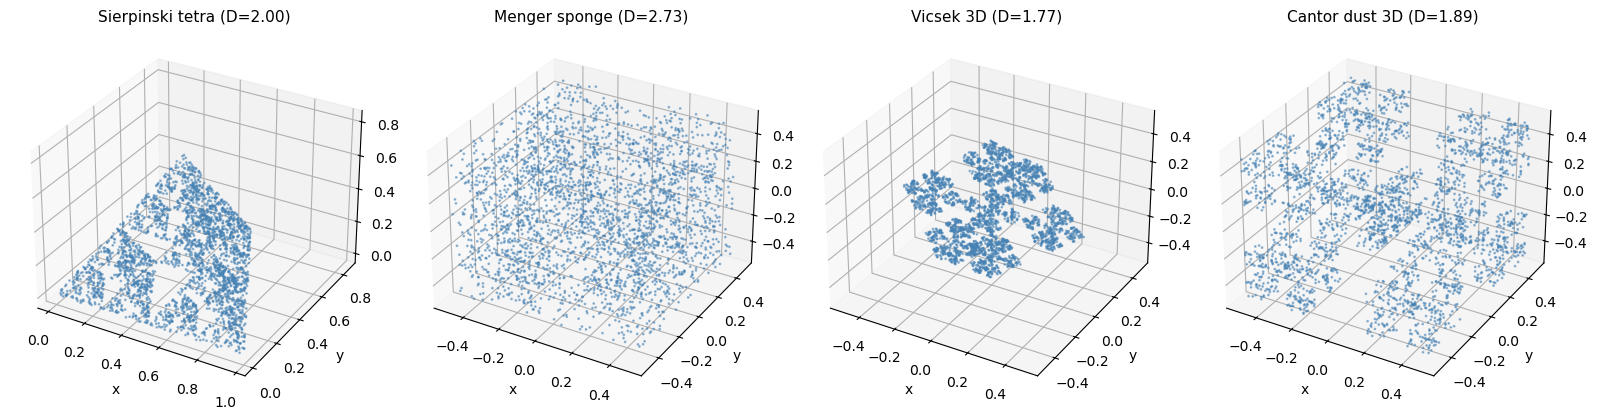

In [ ]:
fractals_3d = {
    'Sierpinski tetra (D=2.00)': X_tetra,
    'Menger sponge (D=2.73)':    X_menger,
    'Vicsek 3D (D=1.77)':        X_vicsek,
    'Cantor dust 3D (D=1.89)':   X_cantor3d,
}

fig = plt.figure(figsize=(16, 4))
for i, (name, X) in enumerate(fractals_3d.items()):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    idx = np.random.default_rng(0).choice(len(X), min(3000, len(X)), replace=False)
    ax.scatter(X[idx,0], X[idx,1], X[idx,2], s=1, c='steelblue', alpha=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# теоретические размерности
theor_D = {
    'Sierpinski tetra': np.log(4)/np.log(2),    # 2.000
    'Menger sponge':    np.log(20)/np.log(3),   # 2.727
    'Vicsek 3D':        np.log(7)/np.log(3),    # 1.771
    'Cantor dust 3D':   np.log(8)/np.log(3),    # 1.893
}

fractals = {
    'Sierpinski tetra': X_tetra,
    'Menger sponge':    X_menger,
    'Vicsek 3D':        X_vicsek,
    'Cantor dust 3D':   X_cantor3d,
}

rows = []
for name, X in fractals.items():
    print(f"\n{name} (N={len(X)}, теор. D = {theor_D[name]:.3f})")

    # D0
    D_box, _ = box_counting_dimension(X, epsilons=None, fit_slice=(0.2, 0.8))
    print(f"D_box = {D_box:.3f}")

    # D2
    D2, _ = correlation_dimension(X, r_vals=None, sample_max=min(5000, len(X)),
                                fit_slice=(0.3, 0.8), seed=0)
    print(f"D2 = {D2:.3f}")

    # D_Schw
    n_s = min(3000, len(X))
    idx_s = np.random.default_rng(0).choice(len(X), n_s, replace=False)
    schw_res = schweinhart_dimension(
        X[idx_s],
        alphas=np.arange(0.5, 3.1, 0.5),
        sample_sizes=np.unique(np.geomspace(50, n_s, 8).astype(int)),
        seed=0,
    )
    D_schw = schw_res['median_d']
    print(f"D_Schw = {D_schw:.3f}")

    # D_Brito
    n_b = min(1500, len(X))
    idx_b = np.random.default_rng(1).choice(len(X), n_b, replace=False)
    brito_res = brito_dimension(X[idx_b], max_dim=10, K=80, sample_size=min(500, n_b), seed=0)
    D_brito = brito_res['d_brito']
    print(f"D_Brito = {D_brito:.3f}")

    rows.append({
        'fractal': name,
        'theor_D': round(theor_D[name], 3),
        'D_box': round(D_box, 3),
        'D2': round(D2, 3),
        'D_Schw': round(D_schw, 3),
        'D_Brito': round(D_brito, 3) if not np.isnan(D_brito) else 'NaN',
    })

df_3d = pd.DataFrame(rows)
print(df_3d.to_string(index=False))



Sierpinski tetra (N=20000, теор. D = 2.000)
D_box = 2.008
D2 = 1.943
D_Schw = 2.011
D_Brito = 2.000

Menger sponge (N=20000, теор. D = 2.727)
D_box = 2.649
D2 = 2.203
D_Schw = 2.593
D_Brito = 3.000

Vicsek 3D (N=16807, теор. D = 1.771)
D_box = 1.839
D2 = 1.793
D_Schw = 1.819
D_Brito = 4.000

Cantor dust 3D (N=20000, теор. D = 1.893)
D_box = 2.077
D2 = 1.861
D_Schw = 1.904
D_Brito = 2.000
         fractal  theor_D  D_box    D2  D_Schw  D_Brito
Sierpinski tetra    2.000  2.008 1.943   2.011        2
   Menger sponge    2.727  2.649 2.203   2.593        3
       Vicsek 3D    1.771  1.839 1.793   1.819        4
  Cantor dust 3D    1.893  2.077 1.861   1.904        2


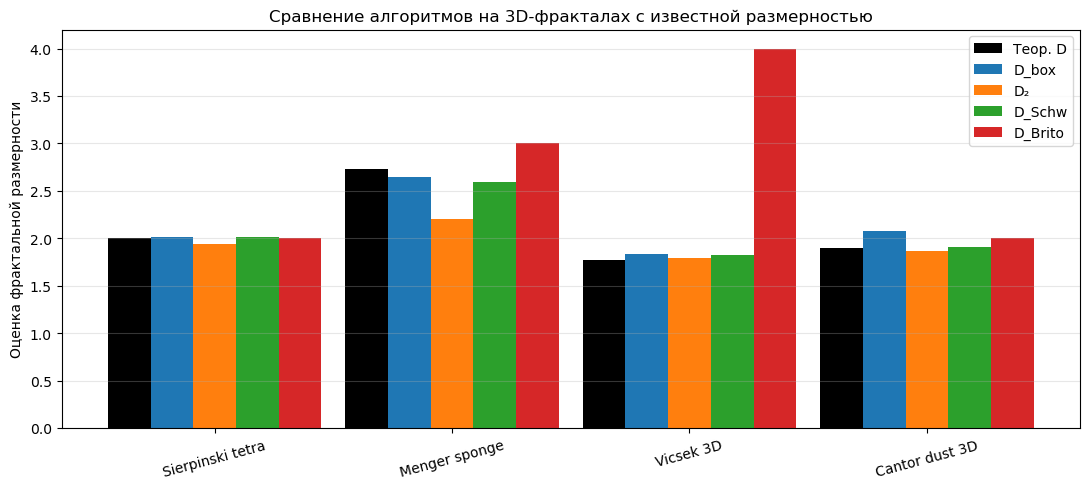

In [ ]:
x = np.arange(len(df_3d))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 2*width, df_3d['theor_D'], width, label='Теор. D', color='black')
ax.bar(x - width, df_3d['D_box'], width, label='D_box', color='tab:blue')
ax.bar(x, df_3d['D2'], width, label='D₂', color='tab:orange')
ax.bar(x + width, df_3d['D_Schw'], width, label='D_Schw', color='tab:green')

brito_vals = pd.to_numeric(df_3d['D_Brito'], errors='coerce').fillna(0)
ax.bar(x + 2*width, brito_vals, width, label='D_Brito', color='tab:red')

ax.set_xticks(x)
ax.set_xticklabels(df_3d['fractal'], rotation=15)
ax.set_ylabel('Оценка фрактальной размерности')
ax.set_title('Сравнение алгоритмов на 3D-фракталах с известной размерностью')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### Конкатенация всего датасета на 1 трек



In [ ]:
import gc
import pickle

loader = MusicNetLoader()
train_tracks = loader.list_tracks('train')

N_TRACKS  = len(train_tracks)
TARGET_SR = 10000

y_big, sr_big = concatenate_tracks(
    loader,
    train_tracks,
    split='train',
    target_sr=TARGET_SR,
)

print(f"Конкатенат: {len(y_big):,} сэмплов = {len(y_big)/sr_big/60:.1f} мин")
gc.collect()


Конкатенат: 1,213,877,815 сэмплов = 2023.1 мин


36119

In [ ]:
hop = 512
n_fft = 2048
S_big = np.abs(librosa.stft(y_big, n_fft=n_fft, hop_length=hop)).astype(np.float32)
print(f"S_big: {S_big.shape}, {S_big.nbytes/1e9:.2f} GB")

embeddings = {
    'centroid':  z_normalize(librosa.feature.spectral_centroid(S=S_big, sr=sr_big)[0]),
    'rms':       z_normalize(librosa.feature.rms(S=S_big)[0]),
    'mfcc1':     z_normalize(librosa.feature.mfcc(
                     S=librosa.power_to_db(S_big**2), sr=sr_big, n_mfcc=13)[1]),
    'bandwidth': z_normalize(librosa.feature.spectral_bandwidth(S=S_big, sr=sr_big)[0]),
    'zcr':       z_normalize(librosa.feature.zero_crossing_rate(y_big, hop_length=hop)[0]),

    # Raw signal
   'wave (ds=10)': z_normalize(
        librosa.resample(y_big.astype(np.float32), orig_sr=sr_big, target_sr=sr_big // 10)
    ),
    'wave (full)':  z_normalize(y_big.astype(np.float32)),
}

del S_big
gc.collect()

print(f"\nРазмеры эмбеддингов:")
for name, x in embeddings.items():
    mb = x.nbytes / 1024**2
    print(f"{name:10s}: {len(x):>10,} точек  ({mb:.2f} MB)")


S_big: (1025, 2370856), 9.72 GB

Размеры эмбеддингов:
centroid  :  2,370,856 точек  (18.09 MB)
rms       :  2,370,856 точек  (18.09 MB)
mfcc1     :  2,370,856 точек  (18.09 MB)
bandwidth :  2,370,856 точек  (18.09 MB)
zcr       :  2,370,856 точек  (18.09 MB)
wave (ds=10): 121,387,782 точек  (926.12 MB)
wave (full): 1,213,877,815 точек  (9261.15 MB)


In [ ]:
def run_all(mode):
    if mode == 'fast':
        M_LIST = (2, 3, 4, 5, 6, 7, 8, 10, 12)
        MAX_LEN = 200_000
        CORR_N = 2500
        SCHW_N = 1500
        AMI_MAX_LAG = 200

    elif mode == 'full':
        M_LIST = (2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20)
        MAX_LEN = 800_000
        CORR_N = 50_000
        SCHW_N = 25_000
        AMI_MAX_LAG = 500

    print(f"Режим: {mode}")
    print(f"m_list = {M_LIST}")
    print(f"corr_sample_max = {CORR_N}, schw_sample_max = {SCHW_N}")
    print(f"AMI max_lag = {AMI_MAX_LAG}\n")

    results_per_emb = {}
    t_total = time.time()

    for name, x in embeddings.items():
        t0 = time.time()
        print(f"\n{name} (N={len(x)})")

        if 'wave (full)' in name:
            this_max = MAX_LEN // 4   # 25K в fast, 75K в full
        elif 'wave' in name:
            this_max = MAX_LEN // 2   # 50K / 150K
        else:
            this_max = MAX_LEN        # 100K / 300K (для centroid и т.п.)

        # выбор τ через AMI (ограничиваем max_lag длиной ряда И MAX_LEN)
        ami_lag = min(AMI_MAX_LAG, len(x) // 4, this_max // 4)
        _, tau_e, _ = average_mutual_information(x, max_lag=ami_lag, ami_min_lag=5)
        tau_e = max(int(tau_e), 1)
        print(f"τ = {tau_e}, max_series_len = {this_max:,}")

        try:
            res = dimension_vs_embedding(
                x, tau=tau_e, m_list=M_LIST,
                corr_sample_max=CORR_N,
                schw_sample_max=SCHW_N,
                max_series_len=this_max,
                seed=0,
            )
            res['tau'] = tau_e
            res['N']   = len(x)
            results_per_emb[name] = res
        except MemoryError as e:
            print(f"OOM на {name}: {e}, пропускаем")
            gc.collect()
            continue
        except Exception as e:
            print(f"Ошибка на {name}: {type(e).__name__}: {e}")
            continue


        gc.collect()
        print(f"Время: {time.time()-t0:.1f} сек")

    print(f"\nОбщее время: {time.time()-t_total:.1f} сек")
    return results_per_emb



In [ ]:
def plot_DM(results_per_emb, mode):
    if mode == 'fast':
        M_LIST = (2, 3, 4, 5, 6, 7, 8, 10, 12)
    elif mode == 'full':
        M_LIST = (2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20)
    else:
        raise ValueError(f"mode must be 'fast' or 'full', got {mode}")

    print(f"Режим: {mode}, эмбеддингов: {len(results_per_emb)}")
    if not results_per_emb:
        print("results_per_emb пустой — нечего рисовать")
        return

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_per_emb)))

    for (name, res), c in zip(results_per_emb.items(), colors):
        label = f"{name} (τ={res['tau']}, N={res['N']:,})"
        ax1.plot(res['m_list'], res['D2'], 'o-', color=c, label=label,
                 linewidth=1.5, markersize=6)
        ax2.plot(res['m_list'], res['D_schw'], 's-', color=c, label=label,
                 linewidth=1.5, markersize=6)

    m_arr = np.array(M_LIST)
    for ax, title in [(ax1, '$D_2$ (correlation) vs $m$'),
                      (ax2, '$D_{Schw}$ (MST) vs $m$')]:
        ax.plot(m_arr, m_arr, 'k:', alpha=0.4, label='$D = m$ (наклон 45°)')
        ax.set_xlabel('Размерность вложения $m$', fontsize=12)
        ax.set_ylabel('Фрактальная размерность', fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'D(m) для конкатената {N_TRACKS} треков '
        f'({len(y_big)/sr_big:.0f} сек), режим: {mode}',
        fontsize=14, y=1.02,
    )
    plt.tight_layout()
    plt.show()


Режим: full
m_list = (2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20)
corr_sample_max = 50000, schw_sample_max = 25000
AMI max_lag = 500


centroid (N=2370856)


τ = 5, max_series_len = 800,000
x trimmed: 2370856 → 800000 (chunk [1336208:2136208])
  m= 2: D2=1.523, D_Schw=2.104, n_corr=50000, n_schw=25000, [107.7s]
  m= 3: D2=1.750, D_Schw=3.267, n_corr=50000, n_schw=25000, [196.3s]
  m= 4: D2=1.892, D_Schw=4.393, n_corr=50000, n_schw=25000, [286.8s]
  m= 5: D2=1.983, D_Schw=5.205, n_corr=50000, n_schw=25000, [377.3s]
  m= 6: D2=2.054, D_Schw=5.884, n_corr=50000, n_schw=25000, [469.1s]
  m= 7: D2=2.113, D_Schw=6.584, n_corr=50000, n_schw=25000, [563.2s]
  m= 8: D2=2.156, D_Schw=7.505, n_corr=50000, n_schw=25000, [658.2s]
  m=10: D2=2.238, D_Schw=8.122, n_corr=40000, n_schw=20000, [713.2s]
  m=12: D2=2.299, D_Schw=9.719, n_corr=40000, n_schw=20000, [771.8s]
  m=15: D2=2.386, D_Schw=11.195, n_corr=28000, n_schw=14000, [803.2s]
  m=18: D2=2.441, D_Schw=13.432, n_corr=28000, n_schw=14000, [831.0s]
  m=20: D2=2.475, D_Schw=13.716, n_corr=28000, n_schw=14000, [859.1s]
Время: 862.3 сек

rms (N=2370856)
τ = 5, max_series_len = 800,000
x trimmed: 237085

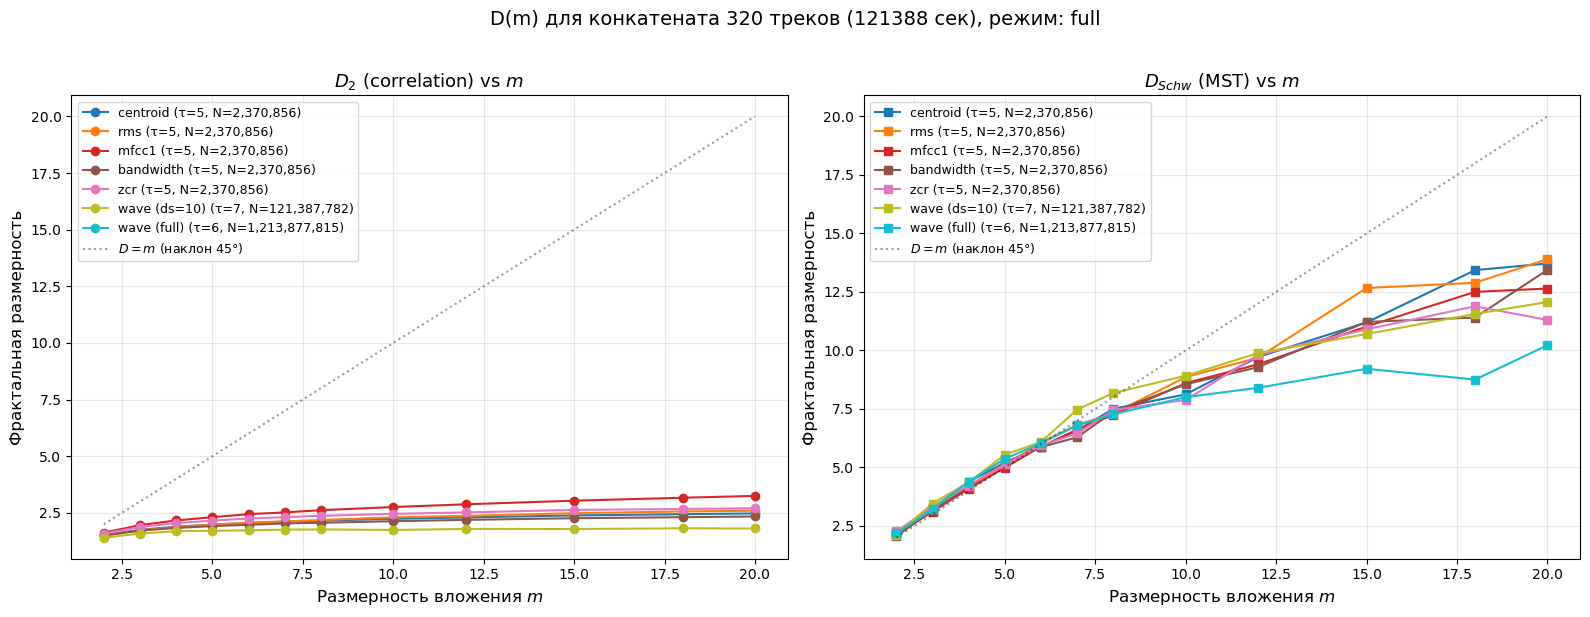

<Figure size 640x480 with 0 Axes>

In [ ]:
MODE = 'full'
results_per_emb = run_all(MODE)

with open(f'{OUT_DIR}/results_per_emb_{MODE}.pkl', 'wb') as f:
    pickle.dump(results_per_emb, f)

gc.collect()
plot_DM(results_per_emb, MODE)
plt.savefig(f'{OUT_DIR}/dim_vs_embedding_{MODE}.png', dpi=100, bbox_inches='tight')


In [ ]:
from scipy.stats import ortho_group


def uniform_cube(N, k, seed=0):
    """Равномерное облако в [0,1]^k → размерность ровно k."""
    rng = np.random.default_rng(seed)
    return rng.uniform(0.0, 1.0, size=(N, k))


def cantor_product(N, k, n_iter=14, seed=0):
    """k копий Кантора → D = k * 0.6309."""
    rng = np.random.default_rng(seed)
    cols = []
    for j in range(k):
        c = cantor_set(n_iter=n_iter).ravel()
        cols.append(c[rng.integers(0, len(c), size=N)])
    return np.column_stack(cols)


def embed_into_RD(X, D_target, seed=0, noise=0.0):
    """
    Вкладывает облако X (N, d_amb) в R^D_target случайным ортогональным поворотом.
    Внутренняя фрактальная размерность сохраняется (изометрия).
    noise — опц. гауссов шум вдоль "лишних" осей (имитирует реальные данные).
    """
    X = np.asarray(X, float)
    N, d_amb = X.shape
    assert D_target >= d_amb, "D_target должна быть >= размерности данных"

    rng = np.random.default_rng(seed)
    # случайная ортонормированная матрица DxD, берём первые d_amb строк
    Q = ortho_group.rvs(D_target, random_state=seed)[:d_amb]  # (d_amb, D_target)
    Y = X @ Q                                                  # (N, D_target)

    if noise > 0:
        Y = Y + rng.normal(0, noise, size=Y.shape)

    return Y


# Тестовый набор: (имя, генератор, D_теор, как готовить точки)
fractal_tests = [
    ('Cantor set',          cantor_set(n_iter=14),                 0.6309),
    ('Koch curve',          koch_curve(n_iter=7),                  1.2619),
    ('Sierpinski triangle', sierpinski_triangle(n_iter=12),        1.5850),
    ('Sierpinski carpet',   sierpinski_carpet(n_iter=6),           1.8928),
    ('Sierp. tetrahedron',  sierpinski_tetrahedron_3d(20000),      2.0000),
    ('Vicsek 3D',           vicsek_3d(n_iter=4, max_points=20000), 1.7712),
    ('Cantor dust 3D',      cantor_dust_3d(n_iter=5, max_points=20000), 1.8928),
    ('Menger sponge 3D',    menger_sponge_3d(n_iter=4, max_points=30000), 2.7268),
]

D_TARGET = 9   # вкладываем все в R^9

rows = []
for name, pts, d_theor in fractal_tests:
    pts = np.asarray(pts, float)
    if pts.ndim == 1:
        pts = pts.reshape(-1, 1)
    n = len(pts)

    # вложение в R^9
    Y = embed_into_RD(pts, D_TARGET, seed=1)

    # D2 (correlation)
    D2, _ = correlation_dimension(Y, sample_max=3000, seed=0)

    # D_box
    D_box, _ = box_counting_dimension(Y)

    # D_Schw (MST)
    schw = schweinhart_dimension(Y, seed=42)
    D_schw = schw['median_d']

    # D_Brito (max_dim берём с запасом над D_target)
    brito = brito_dimension(Y, max_dim=D_TARGET, K=150, sample_size=min(2000, n), seed=0)
    D_brito = brito['d_expected']

    rows.append({
        'Fractal': name,
        'D_theor': d_theor,
        'D_box':   round(D_box, 3),
        'D2':      round(D2, 3),
        'D_Schw':  round(D_schw, 3),
        'D_Brito': round(D_brito, 2),
        'N':       n,
    })

df_embed = pd.DataFrame(rows)
print(f"Все фракталы вложены в R^{D_TARGET} случайным ортогональным поворотом\n")
print(df_embed.to_string(index=False))

Все фракталы вложены в R^9 случайным ортогональным поворотом

            Fractal  D_theor  D_box    D2  D_Schw  D_Brito      N
         Cantor set   0.6309  0.772 0.627   0.631      8.0  16384
         Koch curve   1.2619  1.402 1.222   1.259      2.0  16385
Sierpinski triangle   1.5850  1.644 1.532   1.589      2.0  60001
  Sierpinski carpet   1.8928  1.949 1.684   1.865      2.0 262144
 Sierp. tetrahedron   2.0000  1.860 1.945   2.001      2.0  20000
          Vicsek 3D   1.7712  1.532 1.811   1.716      9.0   2401
     Cantor dust 3D   1.8928  1.809 1.852   1.908      2.0  20000
   Menger sponge 3D   2.7268  2.092 2.200   2.624      3.0  30000


In [39]:
D_TARGET = 10
N_HIGH = 200_000
LOG2_3 = np.log(2) / np.log(3)

high_d_tests = [
    ("uniform R^3", uniform_cube(N_HIGH, 3),   3.0),
    ("uniform R^4", uniform_cube(N_HIGH, 4),   4.0),
    ("uniform R^5", uniform_cube(N_HIGH, 5),   5.0),
    ("uniform R^6", uniform_cube(N_HIGH, 6),   6.0),
    ("uniform R^9", uniform_cube(N_HIGH, 9),   9.0),
    ("uniform R^12", uniform_cube(N_HIGH, 12),   12.0),
    ("uniform R^15", uniform_cube(N_HIGH, 15),   15.0),
    ("uniform R^18", uniform_cube(N_HIGH, 18),   18.0),
    ("Cantor^3", cantor_product(N_HIGH, 3), 3 * LOG2_3),
    ("Cantor^5", cantor_product(N_HIGH, 5), 5 * LOG2_3),
    ("Cantor^7", cantor_product(N_HIGH, 7), 7 * LOG2_3),
    ("Cantor^9", cantor_product(N_HIGH, 9), 9 * LOG2_3),
    ("Cantor^11", cantor_product(N_HIGH, 11), 11 * LOG2_3),
    ("Cantor^13", cantor_product(N_HIGH, 13), 13 * LOG2_3),
    ("Cantor^15", cantor_product(N_HIGH, 15), 15 * LOG2_3),
    ("Cantor^17", cantor_product(N_HIGH, 17), 17 * LOG2_3),
    ("Cantor^19", cantor_product(N_HIGH, 19), 19 * LOG2_3),
]

rows_high = []
print(f"{'object':14s} {'N_min(E-R)':>11s} {'D_theor':>8s} {'D_Schw':>8s} {'err%':>7s}")
for name, X, d_true in high_d_tests:
    d_amb = X.shape[1]
    D_emb = max(D_TARGET, d_amb)        # гарантируем D_emb >= числа столбцов

    Y = embed_into_RD(X, d_amb)
    res = schweinhart_dimension(Y, sample_sizes=[2000, 4000, 8000, 16000, 32000, 64000], seed=42)

    d_est = res['median_d']
    err = 100.0 * (d_est - d_true) / d_true
    n_min = 10 ** (d_true / 2)
    enough = "OK" if N_HIGH >= n_min else "МАЛО"
    rows_high.append((name, d_true, d_est, err, n_min, enough))

    print(f"{name:14s} {n_min:11.0f} {d_true:8.3f} {d_est:8.3f} {err:7.1f}  [{enough}]")

df_high = pd.DataFrame(rows_high, columns=['object', 'D_theor', 'D_Schw', 'err_%', 'N_min_ER', 'sampling'])

object          N_min(E-R)  D_theor   D_Schw    err%
uniform R^3             32    3.000    2.937    -2.1  [OK]
uniform R^4            100    4.000    3.851    -3.7  [OK]
uniform R^5            316    5.000    4.730    -5.4  [OK]
uniform R^6           1000    6.000    5.590    -6.8  [OK]
uniform R^9          31623    9.000    7.973   -11.4  [OK]
uniform R^12       1000000   12.000   10.284   -14.3  [МАЛО]
uniform R^15      31622777   15.000   12.408   -17.3  [МАЛО]
uniform R^18    1000000000   18.000   14.508   -19.4  [МАЛО]
Cantor^3                 9    1.893    1.906     0.7  [OK]
Cantor^5                38    3.155    3.220     2.1  [OK]
Cantor^7               162    4.417    4.313    -2.3  [OK]
Cantor^9               691    5.678    5.885     3.6  [OK]
Cantor^11             2952    6.940    6.947     0.1  [OK]
Cantor^13            12620    8.202    7.870    -4.1  [OK]
Cantor^15            53948    9.464    8.995    -5.0  [OK]
Cantor^17           230623   10.726   10.406    -3.0  [М

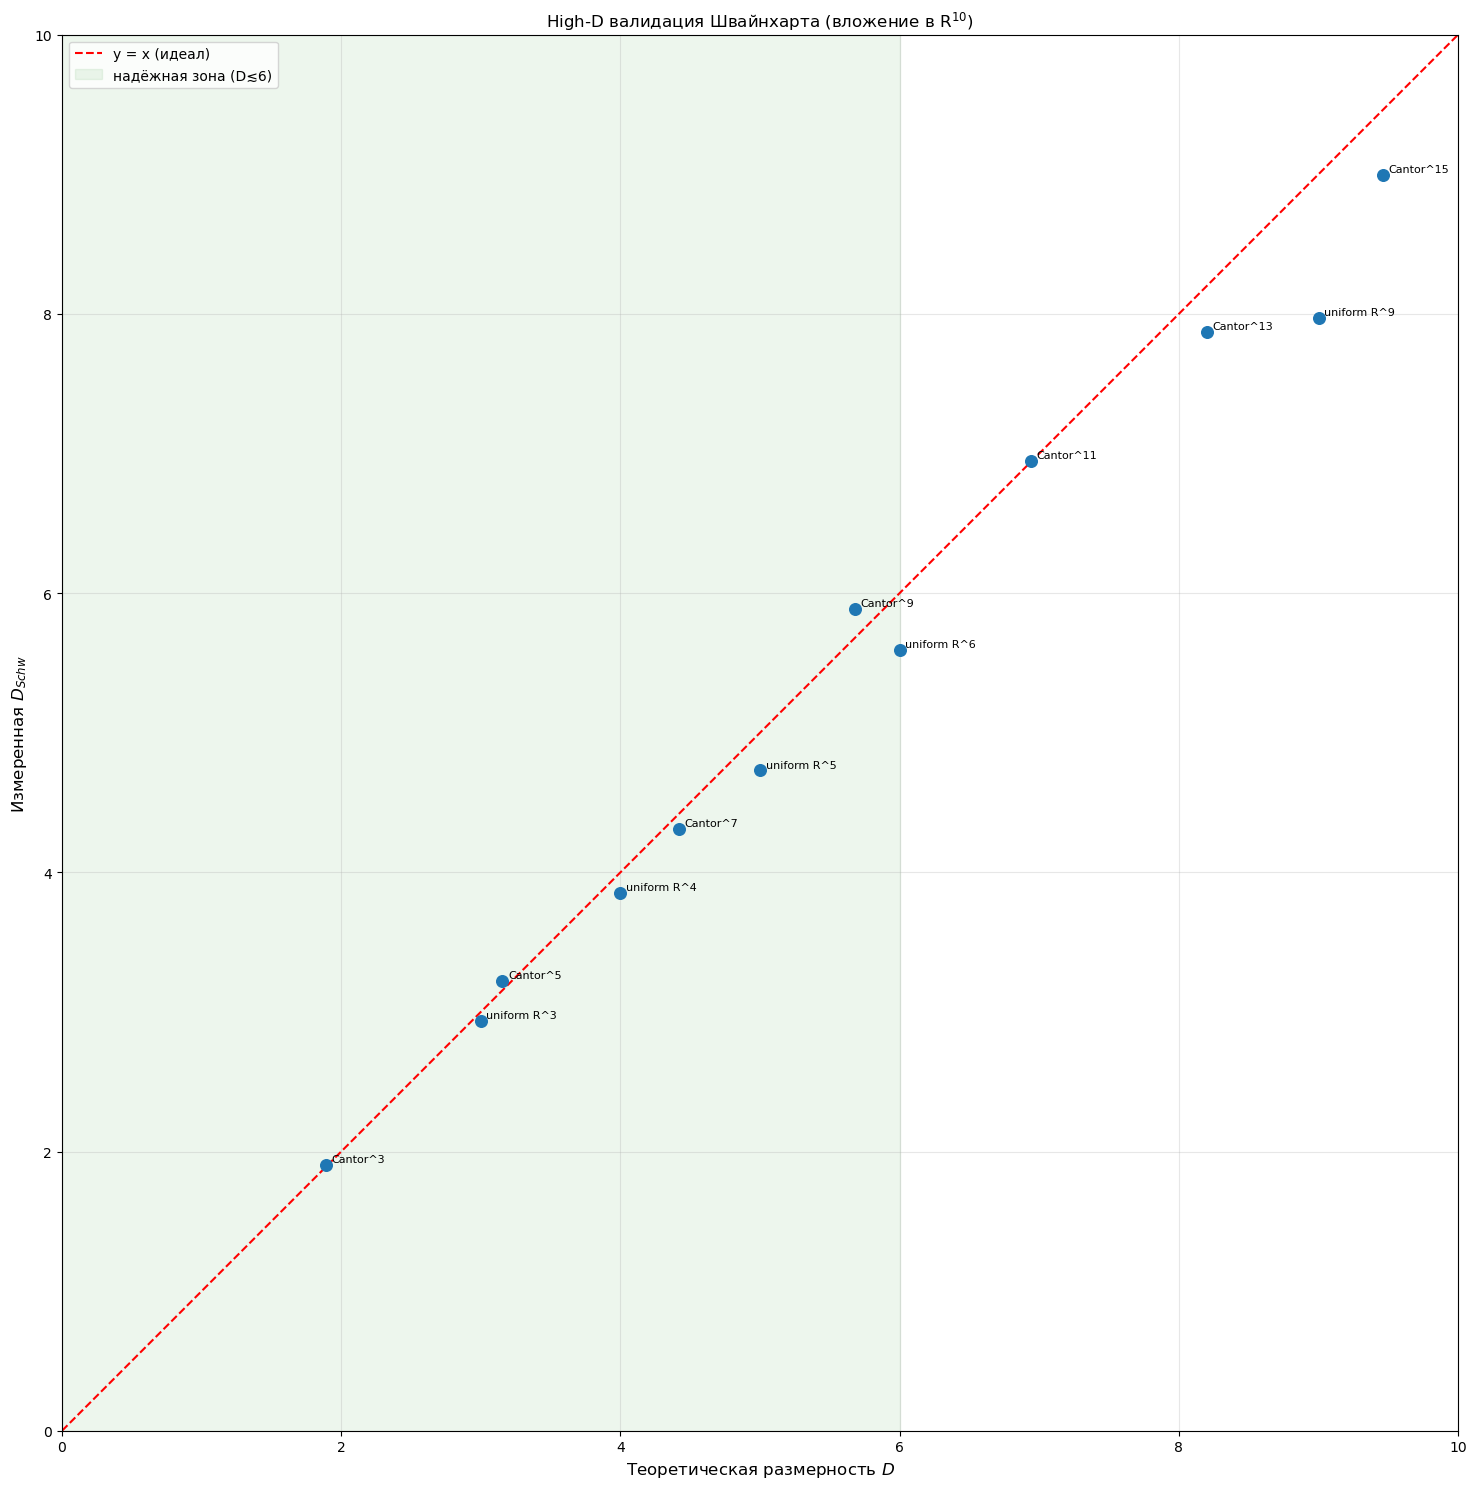

In [43]:
plt.figure(figsize=(15, 15))
plt.scatter(df_high['D_theor'], df_high['D_Schw'], s=70, zorder=3, c='tab:blue')
lims = [0, D_TARGET]
plt.plot(lims, lims, 'r--', label='y = x (идеал)')
plt.axvspan(0, 6, color='green', alpha=0.07, label='надёжная зона (D≲6)')

for _, r in df_high.iterrows():
    plt.annotate(r['object'], (r['D_theor'], r['D_Schw']), fontsize=8, xytext=(4, 2), textcoords='offset points')

plt.xlabel('Теоретическая размерность $D$', fontsize=12)
plt.ylabel('Измеренная $D_{Schw}$', fontsize=12)
plt.title(f'High-D валидация Швайнхарта (вложение в R$^{{{D_TARGET}}}$)', fontsize=12)
plt.xlim(0, D_TARGET)
plt.ylim(0, D_TARGET)
plt.gca().set_aspect('equal')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

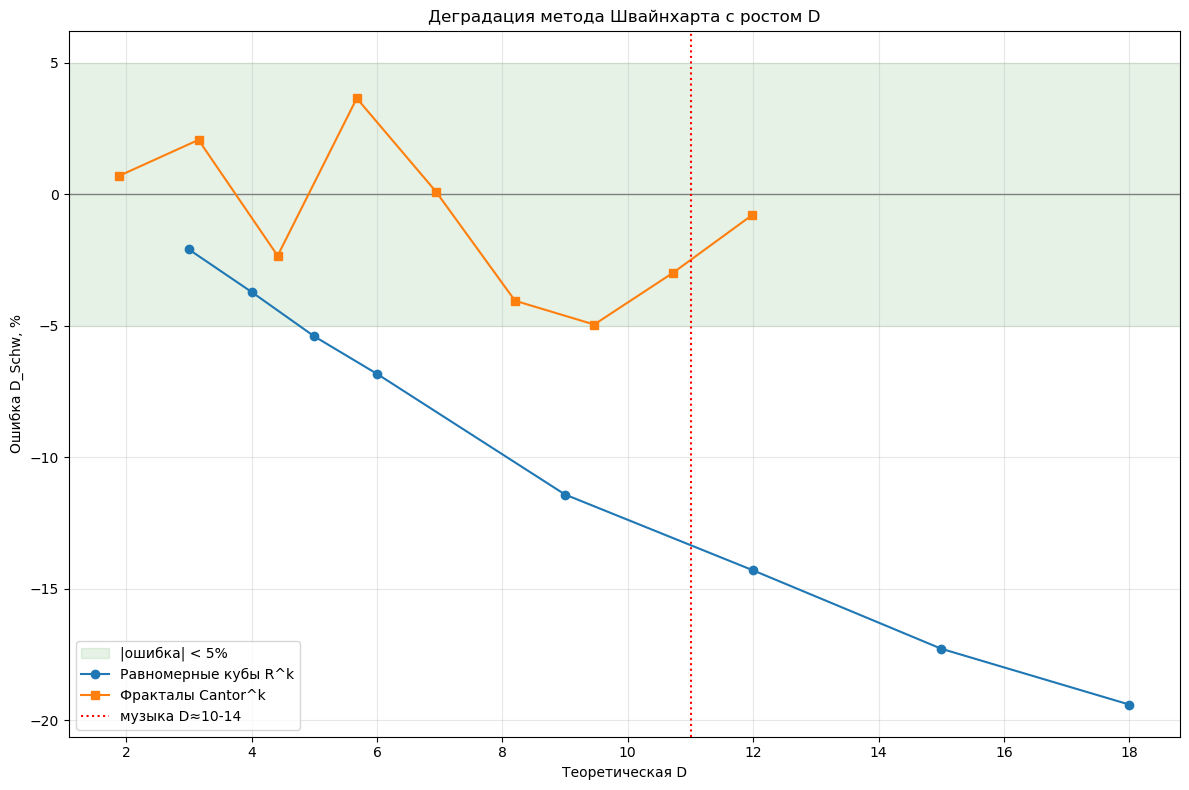

In [42]:
cubes = df_high[df_high['object'].str.startswith('uniform')]
cants = df_high[df_high['object'].str.startswith('Cantor')]
plt.figure(figsize=(12, 8))
plt.axhline(0, color='gray', lw=1)
plt.axhspan(-5, 5, color='green', alpha=0.1, label='|ошибка| < 5%')

plt.plot(cubes['D_theor'], cubes['err_%'], 'o-', label='Равномерные кубы R^k')
plt.plot(cants['D_theor'], cants['err_%'], 's-', label='Фракталы Cantor^k')

plt.axvline(11, color='red', ls=':', label='музыка D≈10-14')
plt.xlabel('Теоретическая D')
plt.ylabel('Ошибка D_Schw, %')
plt.title('Деградация метода Швайнхарта с ростом D')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()